# Phase 1 · Multimodal Clustering Experiments
## DREAMS Memory Analysis Pipeline
### Feature Space: CLIP Image (512D) + Structured Emotion Vector (15D)

**Goal:** Compare multimodal clustering approaches on synthetic memory data matching real pipeline output dimensions. Identify the optimal technique for Phase 1 clustering and produce a clear recommendation for the mentor.

**Working with real-world dimensions:**
- Image embeddings: **512D** from CLIP ViT-B/32 (matches actual pipeline output)
- Emotion vectors: **15D** structured representation (Ekman + circumplex + CHIME)
- These will be reduced via PCA/UMAP and fused using different strategies

### Feature Space Details
| Modality | Source | Dimensions | Description |
|---|---|---|---|
| **Image** | CLIP ViT-B/32 embedding | **512D** | Scene / place visual content — matches real pipeline output |
| **Emotion** | Structured vector from emotion pipeline | **15D** | 7 Ekman emotions + valence + arousal + 5 CHIME one-hot + confidence |

> **Why structured emotion instead of caption embedding?**
> Caption embeddings (384D) and emotion scores are highly correlated (emotions are extracted *from* the caption). Using a structured emotion vector avoids this redundancy, is far more compact (15D vs 384D), and each dimension has a direct, human-interpretable meaning aligned with DREAMS recovery concepts (CHIME: Connectedness, Empowerment, Hope, Identity, Meaning).

### Research-Backed Experiment Plan

| # | Approach | Fusion | Reduction | Clusterer |
|---|---|---|---|---|
| 1 | **Early Fusion** | L2-norm concat (img 512D + emo 15D, weighted 0.6/0.4) → **527D** | PCA → 95% var, then UMAP cosine 10D | HDBSCAN |
| 2 | **Late Fusion** | Per-modality cosine sim + QB-Norm debias + temp scaling | UMAP precomputed 10D | HDBSCAN |
| 3 | **SNF Multi-view** | Mutual k-NN cosine graphs per modality → SNF (T=20) | Spectral embedding of fused graph | HDBSCAN |
| 4 | **KMeans Baseline** | Same Early Fusion concat | PCA only | KMeans (k=6) |

### Dataset (synthetic_dataset4.jsonl — realistic dimensions + harder structure)
- 240 records, 6 balanced clusters (40 each)
- Image embeddings: **512D** — matching real CLIP ViT-B/32 pipeline output
- Emotion vectors: **15D** — structured representation with valence/arousal preserved
- **10% cross-cluster boundary records** (cluster pairs: travel↔outdoors, home↔food, work↔fitness)
- INTRA_STD = 0.90 → clusters deliberately overlap at edges
- CHIME + dominant emotion distributions vary realistically within clusters

### Evaluation Metrics
- **DBCV** — primary metric for HDBSCAN; target > 0.6
- **Silhouette Score** — geometric separation; target > 0.4
- **Bootstrapped ARI** — cluster stability over 50 sub-samples; target > 0.7
- **ARI vs Ground Truth** — true ARI against synthetic cluster labels

### Key Research Insights
1. **k-Means fails in high-D** (arxiv 2602.09936): distance concentration → poor local optima
2. **Cosine hubness** (arxiv 2504.16318): QB-Norm debiasing targets hub-point dominance
3. **UMAP > PCA for density clustering**: preserves local manifold structure for HDBSCAN
4. **SNF** (PMC 7327987): iterative graph fusion handles cluster splits across modalities


In [1]:
# ── Install required packages (run once) ──────────────────────────────────────
import subprocess, sys

def _ensure(pkg, import_as=None):
    name = import_as or pkg
    try:
        __import__(name)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  done.")

_ensure("hdbscan")
_ensure("umap-learn", "umap")

print("All packages available.")


All packages available.


In [2]:
# ── Imports & global config ────────────────────────────────────────────────────
import json, warnings, time, math, pathlib, collections
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.linalg import eigh
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
import hdbscan
import umap

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
REPO_ROOT    = pathlib.Path("../..").resolve()          # DREAMS root
DATASET_PATH = REPO_ROOT / "analysis_pipeline" / "data" / "raw" / "synthetic_dataExp0.jsonl"

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})
PALETTE = sns.color_palette("tab10", 10)

print("Imports done.")
print(f"Dataset path: {DATASET_PATH}")
print(f"Path exists: {DATASET_PATH.exists()}")


Imports done.
Dataset path: C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\analysis_pipeline\data\raw\synthetic_dataExp0.jsonl
Path exists: True


Emotion vector schema: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise', 'valence', 'arousal', 'chime_connectedness', 'chime_empowerment', 'chime_hope', 'chime_identity', 'chime_meaning', 'chime_confidence']

Records : 32
Image emb shape   : (32, 512)
Emotion emb shape : (32, 15)

Proxy label distribution (from location.*):
  faith_space           : 7 records
  clinical_setting      : 6 records
  food_social           : 6 records
  outdoor_nature        : 6 records
  support_service       : 6 records
  residential_support   : 1 records


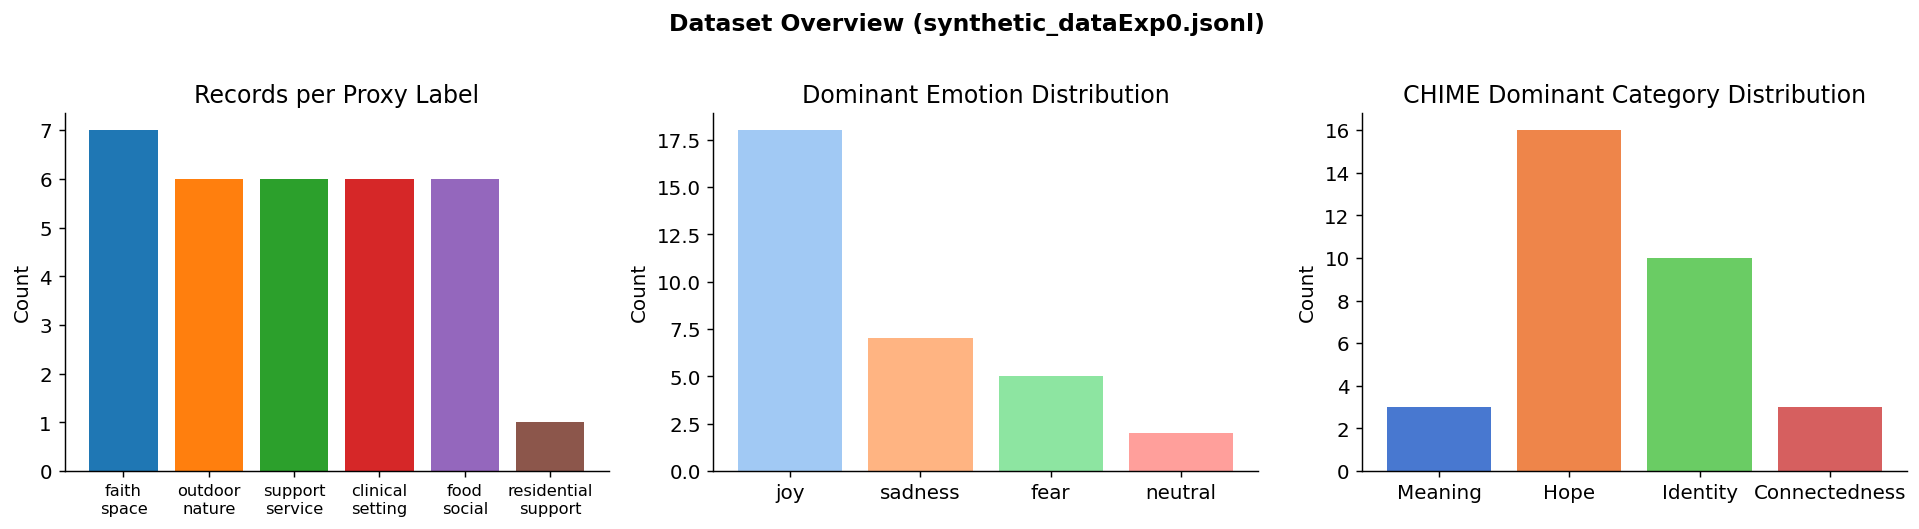

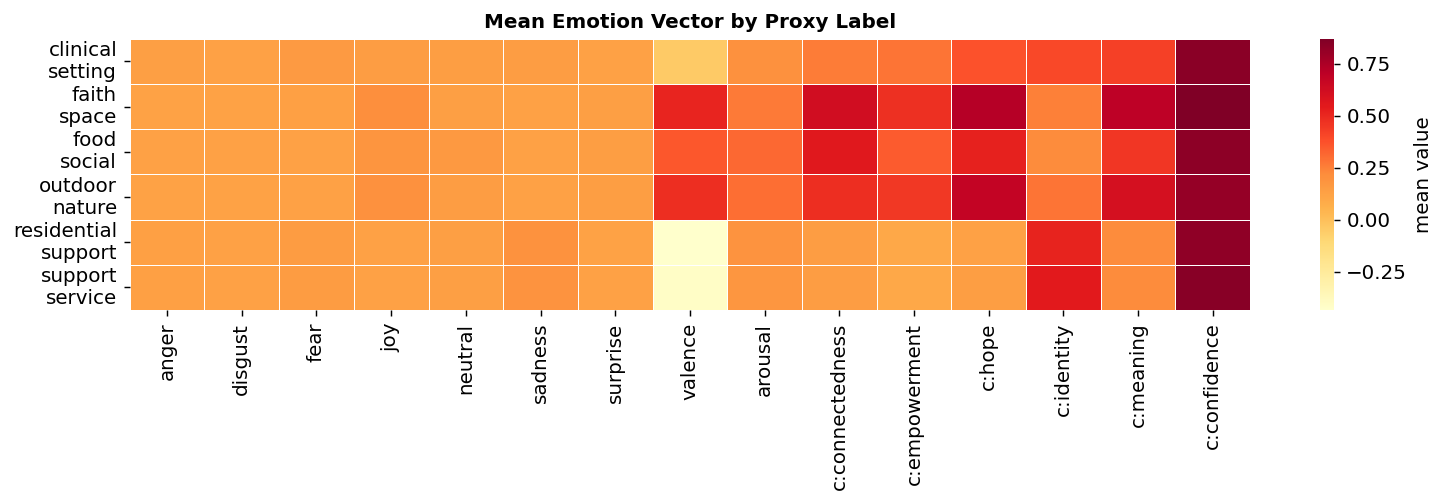

Dataset loaded and verified.


In [3]:
# ── Load dataset & build feature matrices ─────────────────────────────────────

records = [json.loads(l) for l in open(DATASET_PATH, encoding="utf-8")]
df = pd.json_normalize(records)

N = len(records)
IMG_D = records[0]["embeddings"]["image"]["dimensions"]

# ── Build a 15D structured emotion vector from this dataset's schema ─────────
# 15D = 7 discrete + 2 circumplex + 5 CHIME + 1 CHIME confidence
EMO_SCHEMA = [
    "anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise",
    "valence", "arousal",
    "chime_connectedness", "chime_empowerment", "chime_hope", "chime_identity", "chime_meaning",
    "chime_confidence",
]
EMO_D = len(EMO_SCHEMA)

def build_emo_vec(r):
    d = r.get("emotions", {})
    disc = d.get("discrete", {})
    ch = d.get("chime", {})
    return [
        float(disc.get("anger", 0.0)),
        float(disc.get("disgust", 0.0)),
        float(disc.get("fear", 0.0)),
        float(disc.get("joy", 0.0)),
        float(disc.get("neutral", 0.0)),
        float(disc.get("sadness", 0.0)),
        float(disc.get("surprise", 0.0)),
        float(d.get("valence", 0.0)),
        float(d.get("arousal", 0.0)),
        float(ch.get("connectedness", 0.0)),
        float(ch.get("empowerment", 0.0)),
        float(ch.get("hope", 0.0)),
        float(ch.get("identity", 0.0)),
        float(ch.get("meaning", 0.0)),
        float(ch.get("confidence", 0.0)),
    ]

print("Emotion vector schema:", EMO_SCHEMA)

# Raw embedding matrices
X_img = np.array([r["embeddings"]["image"]["vector"] for r in records], dtype=np.float32)
X_emo = np.array([build_emo_vec(r) for r in records], dtype=np.float32)

# "Ground truth" labels for evaluation only (dataset has no synthetic cluster_id)
# Use location category mapping as a proxy label so later ARI/plots still run.
def get_proxy_label(r):
    loc = r.get("location", {})
    return loc.get("place_category_mapped") or loc.get("place_type") or "unknown"

y_proxy = [get_proxy_label(r) for r in records]
y_true = pd.Categorical(y_proxy).codes.astype(int)
THEME_NAMES = y_proxy
THEME_LABELS = list(pd.Categorical(y_proxy).categories)

print(f"\nRecords : {N}")
print(f"Image emb shape   : {X_img.shape}")
print(f"Emotion emb shape : {X_emo.shape}")

print(f"\nProxy label distribution (from location.*):")
for name, cnt in sorted(collections.Counter(THEME_NAMES).items(), key=lambda x: (-x[1], x[0])):
    print(f"  {name:22s}: {cnt} records")

# ── Quick dataset EDA ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Records per proxy label (top 10)
top_labels = [k for k, _ in collections.Counter(THEME_NAMES).most_common(10)]
counts = [collections.Counter(THEME_NAMES)[k] for k in top_labels]
axes[0].bar(range(len(top_labels)), counts, color=sns.color_palette("tab10", len(top_labels)))
axes[0].set_xticks(range(len(top_labels)))
axes[0].set_xticklabels([t.replace("_", "\n") for t in top_labels], fontsize=9)
axes[0].set_title("Records per Proxy Label")
axes[0].set_ylabel("Count")

# 2. Dominant emotions
emotions_dist = collections.Counter(r.get("emotions", {}).get("dominant_emotion", "unknown") for r in records)
axes[1].bar(emotions_dist.keys(), emotions_dist.values(),
            color=sns.color_palette("pastel", len(emotions_dist)))
axes[1].set_title("Dominant Emotion Distribution")
axes[1].set_ylabel("Count")

# 3. CHIME dominant category distribution
chime_dist = collections.Counter(r.get("emotions", {}).get("chime", {}).get("dominant_category", "unknown") for r in records)
axes[2].bar(chime_dist.keys(), chime_dist.values(),
            color=sns.color_palette("muted", len(chime_dist)))
axes[2].set_title("CHIME Dominant Category Distribution")
axes[2].set_ylabel("Count")

plt.suptitle("Dataset Overview (synthetic_dataExp0.jsonl)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 2D emotion profile heatmap ─────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 4))
emo_means_by_cluster = np.array([
    X_emo[y_true == cid].mean(axis=0) for cid in range(len(THEME_LABELS))
])
sns.heatmap(
    emo_means_by_cluster,
    xticklabels=[s.replace("chime_", "c:") for s in EMO_SCHEMA],
    yticklabels=[THEME_LABELS[i].replace("_", "\n") for i in range(len(THEME_LABELS))],
    annot=False, cmap="YlOrRd", ax=ax2, linewidths=0.3,
    cbar_kws={"label": "mean value"},
)
ax2.set_title("Mean Emotion Vector by Proxy Label", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("Dataset loaded and verified.")


---
## Experiment 1 — Early Fusion
**Approach:** Separately L2-normalize each modality, then concatenate with weights (0.6 image / 0.4 emotion). Reduce with PCA to capture 95% variance, then UMAP (cosine metric, 10 components). Cluster with HDBSCAN.

**Feature vector:** `img (512D, L2-normed × 0.6) ‖ emo (15D, L2-normed × 0.4)` → **527D concat**.

**Why emotion over caption embedding:**
- Caption embedding (384D sentence embedding) is derived from the same text that produced the emotion scores → high correlation → redundant signal
- The 15D emotion vector is far more compact, interpretable, and directly encodes DREAMS-aligned constructs (CHIME recovery dimensions, Russell circumplex, Ekman categories)
- Replacing 384D caption with 15D emotion reduces the fusion space from 896D (512+384) to 527D (512+15), lowering the PCA components needed and speeding up UMAP convergence

**Why early fusion is a strong baseline:** FuseLIP (arxiv 2506.03096) shows concatenating normalized embeddings before dimensionality reduction allows modality interaction during the reduction step — outperforming post-hoc similarity averaging.

**Key design choices:**
- L2 normalization prevents image embedding (512D) from dominating emotion (15D)
- Weighted concat (0.6/0.4): image embeddings carry richer spatial/scene signal
- UMAP cosine: preserves angular similarity structure for normalized vectors
- HDBSCAN: handles variable-density clusters; produces noise labels for outlier memories


Concatenated shape: (32, 527)  (IMG=512D + EMO=15D = 527D)
After PCA (95% var): (32, 28)  —  28 components


After UMAP: (32, 10)  [35.0s]

HDBSCAN found 2 clusters
Noise points : 0 (0.0%)
Cluster sizes: [19, 13]


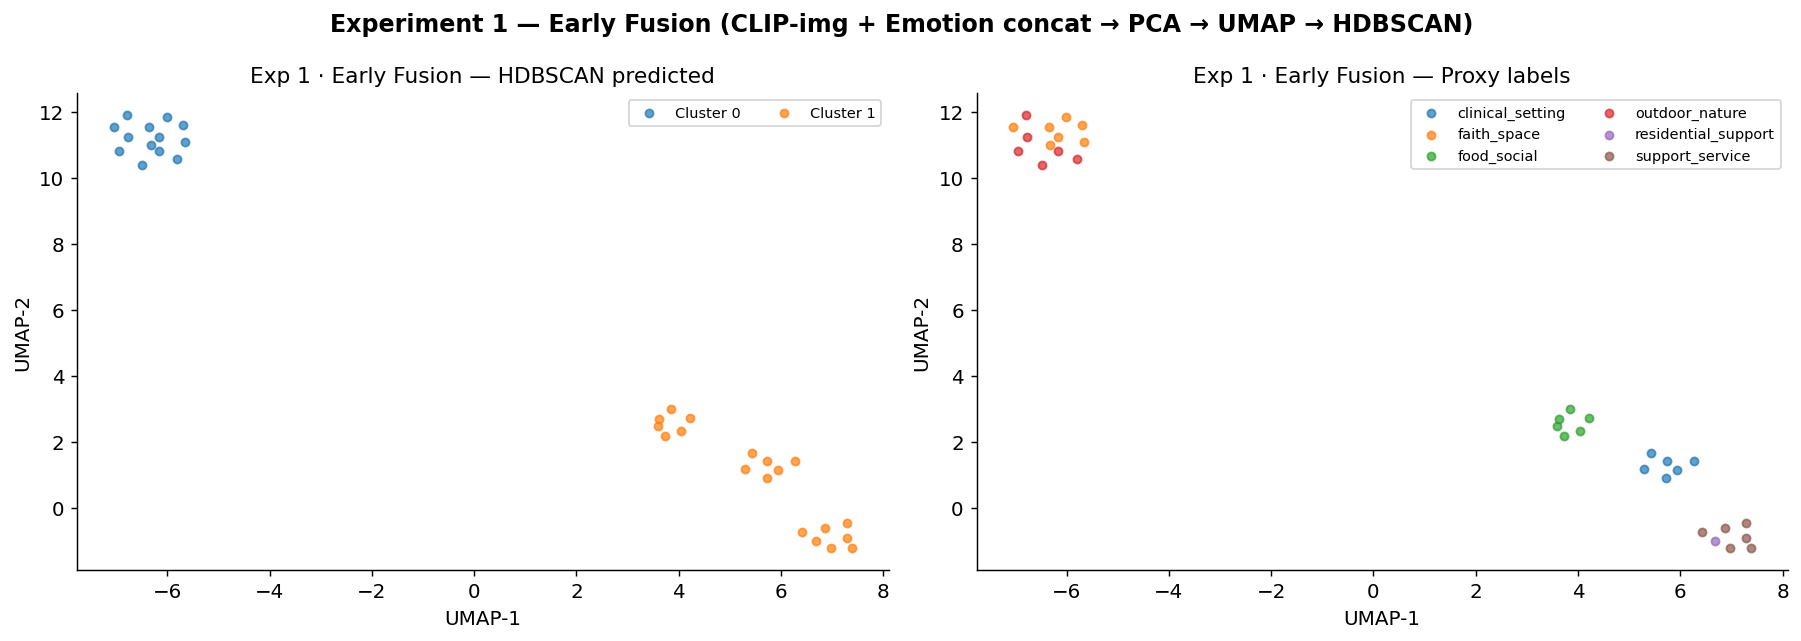

In [4]:
# ── Experiment 1: Early Fusion ─────────────────────────────────────────────────

W_IMG  = 0.6    # image modality weight  (richer scene/place signal)
W_EMO  = 0.4    # emotion modality weight

# Step 1: L2-normalize each modality independently
# Note: emotion vector is already in [0,1] except discrete probs sum to 1 —
# L2-norm still helps because the CHIME one-hot dims have very different scale vs valence
X_img_n  = normalize(X_img,  norm="l2")
X_emo_n  = normalize(X_emo,  norm="l2")

# Step 2: Weighted concatenation → (N, 512+15) = (N, 527)
X_early  = np.hstack([W_IMG * X_img_n, W_EMO * X_emo_n])
print(f"Concatenated shape: {X_early.shape}  (IMG={IMG_D}D + EMO={EMO_D}D = {IMG_D+EMO_D}D)")

# Step 3: PCA → retain 95% variance (reduces noise, speeds UMAP)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_early)
print(f"After PCA (95% var): {X_pca.shape}  —  {pca.n_components_} components")

# Step 4: UMAP → cosine metric, 10 components (manifold for HDBSCAN)
t0 = time.time()
reducer_early = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=10,
    metric="cosine",
    random_state=42,
    verbose=False,
)
X_umap_early = reducer_early.fit_transform(X_pca)
print(f"After UMAP: {X_umap_early.shape}  [{time.time()-t0:.1f}s]")

# Step 5: HDBSCAN clustering
hdb_early = hdbscan.HDBSCAN(
    min_cluster_size=max(5, int(0.08 * len(records))),   # ~8%
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
labels_early = hdb_early.fit_predict(X_umap_early)

n_clusters_early = len(set(labels_early)) - (1 if -1 in labels_early else 0)
noise_pct_early  = 100 * (labels_early == -1).sum() / N

print(f"\nHDBSCAN found {n_clusters_early} clusters")
print(f"Noise points : {(labels_early==-1).sum()} ({noise_pct_early:.1f}%)")
print(f"Cluster sizes: {sorted(collections.Counter(labels_early[labels_early!=-1]).values(), reverse=True)}")

# Step 6: 2-D UMAP for visualization only  
reducer_2d_early = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                              metric="cosine", random_state=42, verbose=False)
X_2d_early = reducer_2d_early.fit_transform(X_pca)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Predicted labels
for lbl in sorted(set(labels_early)):
    mask = labels_early == lbl
    color = "lightgrey" if lbl == -1 else PALETTE[lbl % len(PALETTE)]
    label_str = "Noise" if lbl == -1 else f"Cluster {lbl}"
    ax1.scatter(X_2d_early[mask, 0], X_2d_early[mask, 1],
                c=[color], s=20, alpha=0.7, label=label_str)
ax1.set_title("Exp 1 · Early Fusion — HDBSCAN predicted", fontsize=12)
ax1.legend(fontsize=8, ncol=2)
ax1.set_xlabel("UMAP-1"); ax1.set_ylabel("UMAP-2")

# Ground truth labels (proxy labels derived from location.*)
for cid in range(len(THEME_LABELS)):
    mask = y_true == cid
    ax2.scatter(X_2d_early[mask, 0], X_2d_early[mask, 1],
                c=[PALETTE[cid % len(PALETTE)]], s=20, alpha=0.7, label=THEME_LABELS[cid])
ax2.set_title("Exp 1 · Early Fusion — Proxy labels", fontsize=12)
ax2.legend(fontsize=8, ncol=2)
ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2")

plt.suptitle("Experiment 1 — Early Fusion (CLIP-img + Emotion concat → PCA → UMAP → HDBSCAN)",
             fontweight="bold")
plt.tight_layout()
plt.show()


---
## Experiment 2 — Late Fusion with QB-Norm Debiasing
**Approach:** Compute a separate cosine similarity matrix per modality (image 64D, emotion 15D). Apply **QB-Norm** (Query-Biased Normalization) to reduce hubness. Apply temperature scaling per modality, then average-weight the matrices. UMAP on the precomputed fused similarity, then HDBSCAN.

**Why QB-Norm matters here:** The image modality (64D) and emotion modality (15D) have different intrinsic dimensionalities and hub-point tendencies. QB-Norm recenters each query's similarity distribution independently per modality before fusing — this is especially important now that we replaced the 48D caption embedding with a 15D structured vector, since the low-rank structure of the emotion space can create strong hubs in cosine similarity.

**Key design choices:**
- QB-Norm with k=20 background samples for debiasing
- Temperature scaling (τ=0.1, as used in CLIP) to calibrate similarity sharpness
- Weighted average: 0.6 image / 0.4 emotion (same as Exp 1 for fair comparison)
- UMAP on precomputed similarity (dist = 1 - sim)


Computing per-modality cosine similarity matrices...
  Raw sim matrices: img=(32, 32), emo=(32, 32)  [0.0s]
Applying QB-Norm debiasing...
  QB-Norm done  [0.0s]
Applying temperature scaling and weighted fusion...
Running UMAP on precomputed distance matrix...
  UMAP done: (32, 10)  [0.2s]

HDBSCAN found 4 clusters
Noise points : 0 (0.0%)
Cluster sizes: [13, 7, 6, 6]

Hubness skewness  before QB-Norm+UMAP: 0.670
Hubness skewness  after  QB-Norm+UMAP: 0.716
(Lower skew = less hubness. >2.0 is problematic)


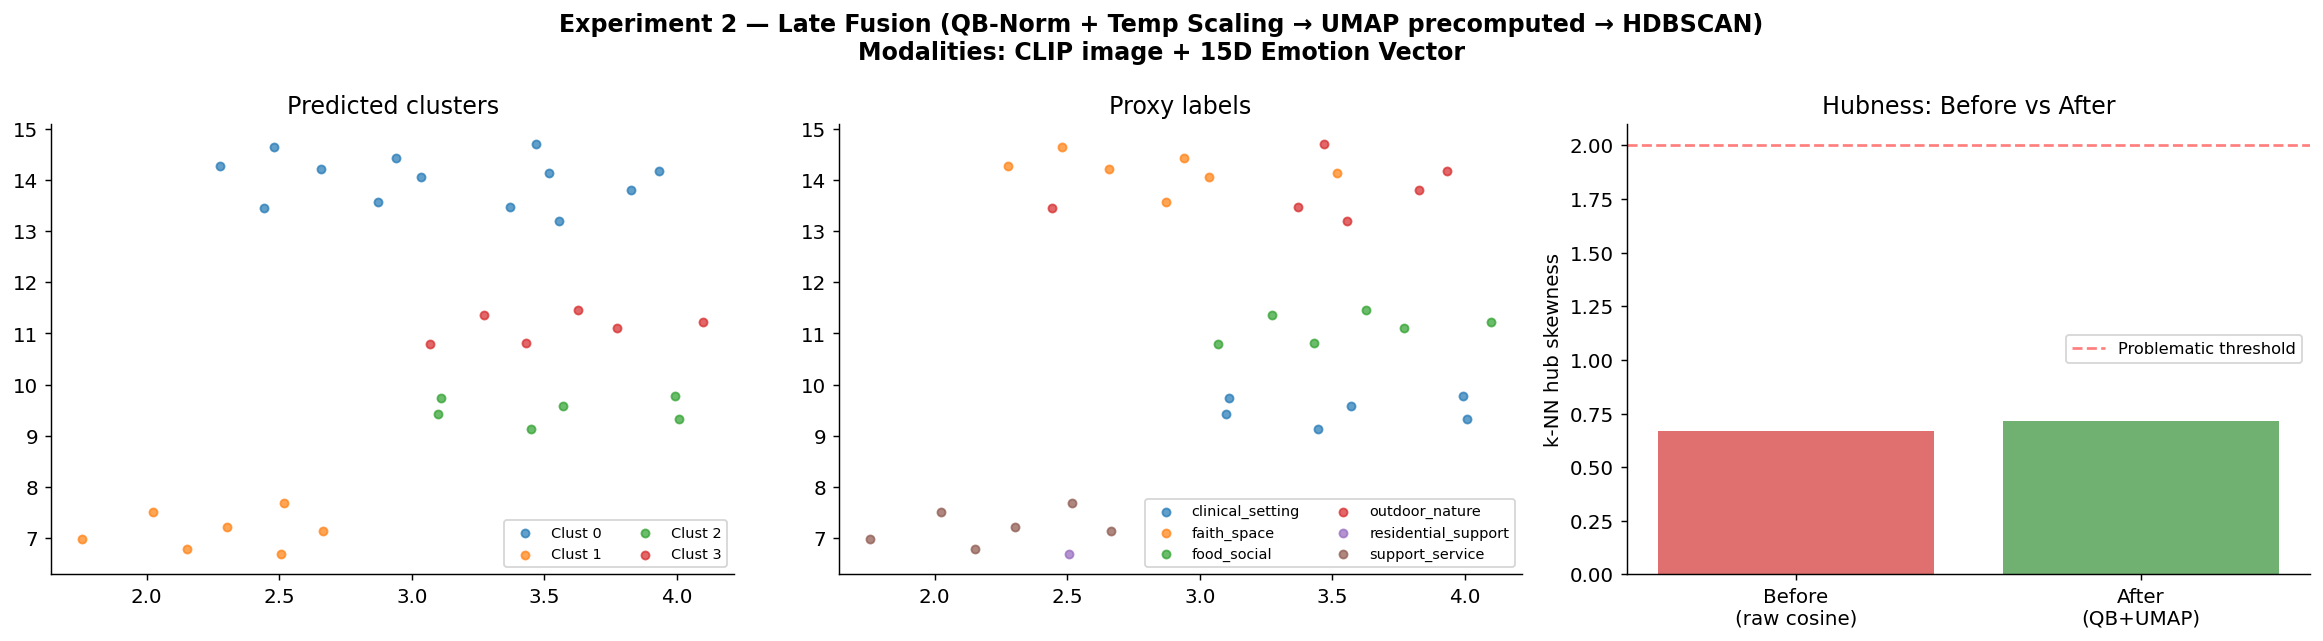

In [5]:
# ── Experiment 2: Late Fusion ──────────────────────────────────────────────────

TEMP      = 0.1    # temperature scaling (CLIP-style)
QB_K      = 20     # QB-Norm background sample count
W_IMG_LF  = 0.6
W_EMO_LF  = 0.4

def cosine_sim_matrix(X):
    """Compute full N×N cosine similarity matrix (values in [-1, 1])."""
    Xn = normalize(X, norm="l2")
    return Xn @ Xn.T

def qb_norm(S, k=20):
    """Query-Biased Normalization: subtract per-query mean similarity
    over the k-nearest background samples (excluding self).
    Reduces hubness by recentering the similarity distribution.
    """
    S_out = S.copy()
    N = S.shape[0]
    for i in range(N):
        row = S[i].copy()
        row[i] = -np.inf                          # exclude self
        top_k_idx = np.argpartition(row, -k)[-k:] # k nearest
        bias = S[i, top_k_idx].mean()
        S_out[i] -= bias
        S_out[:, i] -= bias                        # symmetric bias removal
    np.fill_diagonal(S_out, 1.0)                  # restore diagonal
    return S_out

def temp_scale(S, tau):
    """Temperature-calibrated similarity (CLIP-style: S / tau, then softmax row-wise)."""
    S_scaled = S / tau
    S_scaled = np.clip(S_scaled, -30, 30)
    mins = S_scaled.min(axis=1, keepdims=True)
    rngs = S_scaled.max(axis=1, keepdims=True) - mins + 1e-8
    return (S_scaled - mins) / rngs

print("Computing per-modality cosine similarity matrices...")
t0 = time.time()
S_img = cosine_sim_matrix(X_img)
S_emo = cosine_sim_matrix(X_emo)
print(f"  Raw sim matrices: img={S_img.shape}, emo={S_emo.shape}  [{time.time()-t0:.1f}s]")

print("Applying QB-Norm debiasing...")
t0 = time.time()
S_img_qb = qb_norm(S_img, k=QB_K)
S_emo_qb = qb_norm(S_emo, k=QB_K)
print(f"  QB-Norm done  [{time.time()-t0:.1f}s]")

print("Applying temperature scaling and weighted fusion...")
S_img_ts = temp_scale(S_img_qb, TEMP)
S_emo_ts = temp_scale(S_emo_qb, TEMP)
S_fused  = W_IMG_LF * S_img_ts + W_EMO_LF * S_emo_ts

D_fused = 1.0 - S_fused
np.fill_diagonal(D_fused, 0.0)
D_fused = np.clip(D_fused, 0.0, None)

print("Running UMAP on precomputed distance matrix...")
t0 = time.time()
reducer_late = umap.UMAP(
    n_neighbors=30,
    n_components=10,
    metric="precomputed",
    random_state=42,
    verbose=False,
)
X_umap_late = reducer_late.fit_transform(D_fused)
print(f"  UMAP done: {X_umap_late.shape}  [{time.time()-t0:.1f}s]")

hdb_late = hdbscan.HDBSCAN(
    min_cluster_size=max(5, int(0.08 * N)),
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
labels_late = hdb_late.fit_predict(X_umap_late)

n_clusters_late = len(set(labels_late)) - (1 if -1 in labels_late else 0)
noise_pct_late  = 100 * (labels_late == -1).sum() / N
print(f"\nHDBSCAN found {n_clusters_late} clusters")
print(f"Noise points : {(labels_late==-1).sum()} ({noise_pct_late:.1f}%)")
print(f"Cluster sizes: {sorted(collections.Counter(labels_late[labels_late!=-1]).values(), reverse=True)}")

reducer_2d_late = umap.UMAP(n_neighbors=30, n_components=2, metric="precomputed",
                             random_state=42, verbose=False)
X_2d_late = reducer_2d_late.fit_transform(D_fused)

# ── Hubness diagnostic ──────────────────────────────────────────────────────
KNN = 10
from sklearn.neighbors import NearestNeighbors
nbrs_before = NearestNeighbors(n_neighbors=KNN+1, metric="cosine").fit(normalize(X_img, "l2"))
_, inds_before = nbrs_before.kneighbors(normalize(X_img, "l2"))
inds_before = inds_before[:, 1:]

hub_before = np.bincount(inds_before.flatten(), minlength=N)
skew_before = float(np.mean((hub_before - hub_before.mean())**3) / (hub_before.std()**3 + 1e-8))

nbrs_after = NearestNeighbors(n_neighbors=KNN+1, metric="cosine").fit(X_umap_late)
_, inds_after = nbrs_after.kneighbors(X_umap_late)
inds_after = inds_after[:, 1:]
hub_after = np.bincount(inds_after.flatten(), minlength=N)
skew_after = float(np.mean((hub_after - hub_after.mean())**3) / (hub_after.std()**3 + 1e-8))
print(f"\nHubness skewness  before QB-Norm+UMAP: {skew_before:.3f}")
print(f"Hubness skewness  after  QB-Norm+UMAP: {skew_after:.3f}")
print("(Lower skew = less hubness. >2.0 is problematic)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for lbl in sorted(set(labels_late)):
    mask = labels_late == lbl
    c = "lightgrey" if lbl == -1 else PALETTE[lbl % len(PALETTE)]
    axes[0].scatter(X_2d_late[mask, 0], X_2d_late[mask, 1], c=[c], s=20, alpha=0.7,
                    label="Noise" if lbl==-1 else f"Clust {lbl}")
axes[0].set_title("Predicted clusters"); axes[0].legend(fontsize=8, ncol=2)

for cid in range(len(THEME_LABELS)):
    mask = y_true == cid
    axes[1].scatter(X_2d_late[mask, 0], X_2d_late[mask, 1], c=[PALETTE[cid % len(PALETTE)]], s=20, alpha=0.7,
                    label=THEME_LABELS[cid])
axes[1].set_title("Proxy labels"); axes[1].legend(fontsize=8, ncol=2)

axes[2].bar(["Before\n(raw cosine)", "After\n(QB+UMAP)"], [skew_before, skew_after],
            color=["#e07070", "#70b070"])
axes[2].axhline(2.0, color="red", linestyle="--", alpha=0.5, label="Problematic threshold")
axes[2].set_ylabel("k-NN hub skewness"); axes[2].set_title("Hubness: Before vs After")
axes[2].legend(fontsize=9)

plt.suptitle("Experiment 2 — Late Fusion (QB-Norm + Temp Scaling → UMAP precomputed → HDBSCAN)\n"
             "Modalities: CLIP image + 15D Emotion Vector",
             fontweight="bold")
plt.tight_layout()
plt.show()


---
## Experiment 3 — Similarity Network Fusion (SNF) Multi-view
**Approach:** Build a mutual k-NN cosine similarity graph per modality (image + emotion). Apply SNF (T=20 diffusion iterations, α=0.5) to combine them into a single consensus graph. Extract embeddings from the fused graph via spectral decomposition, then HDBSCAN.

**Why SNF is interesting for memory clustering with the emotion modality:** Real memory clusters often disagree between image and emotion signals. For example, a "fitness_health" memory at a gym in Tokyo might have a high-valence, high-arousal emotion profile (Empowerment) that resembles a "travel_landmarks" memory emotionally — but visually they're distinct. SNF's iterative diffusion mediates this disagreement and surfaces consensus clusters rather than being dominated by one modality.

**Key design choices:**
- Mutual k-NN (k=15): reduces hubness before fusion, especially relevant for the low-dimensional emotion space
- SNF diffusion (T=20): convergence is fast for N=240; at T=20 the fused graph stabilises
- Spectral embedding from fused graph: captures non-linear cluster structure
- DBCV < 0.4 → fallback to mean aggregation (per arxiv 2502.15993)


Building mutual k-NN graphs per modality...
  Graphs built  [0.0s]
Running SNF (T=20, alpha=0.5)...
  SNF done  [0.0s]
  NaN/Inf in fused matrix after sanitization: 0  (should be 0)
Spectral embedding (10D, sklearn SpectralEmbedding)...
  Spectral embedding: (32, 10)  [0.0s]

HDBSCAN found 0 clusters
Noise points : 32 (100.0%)
Cluster sizes: []


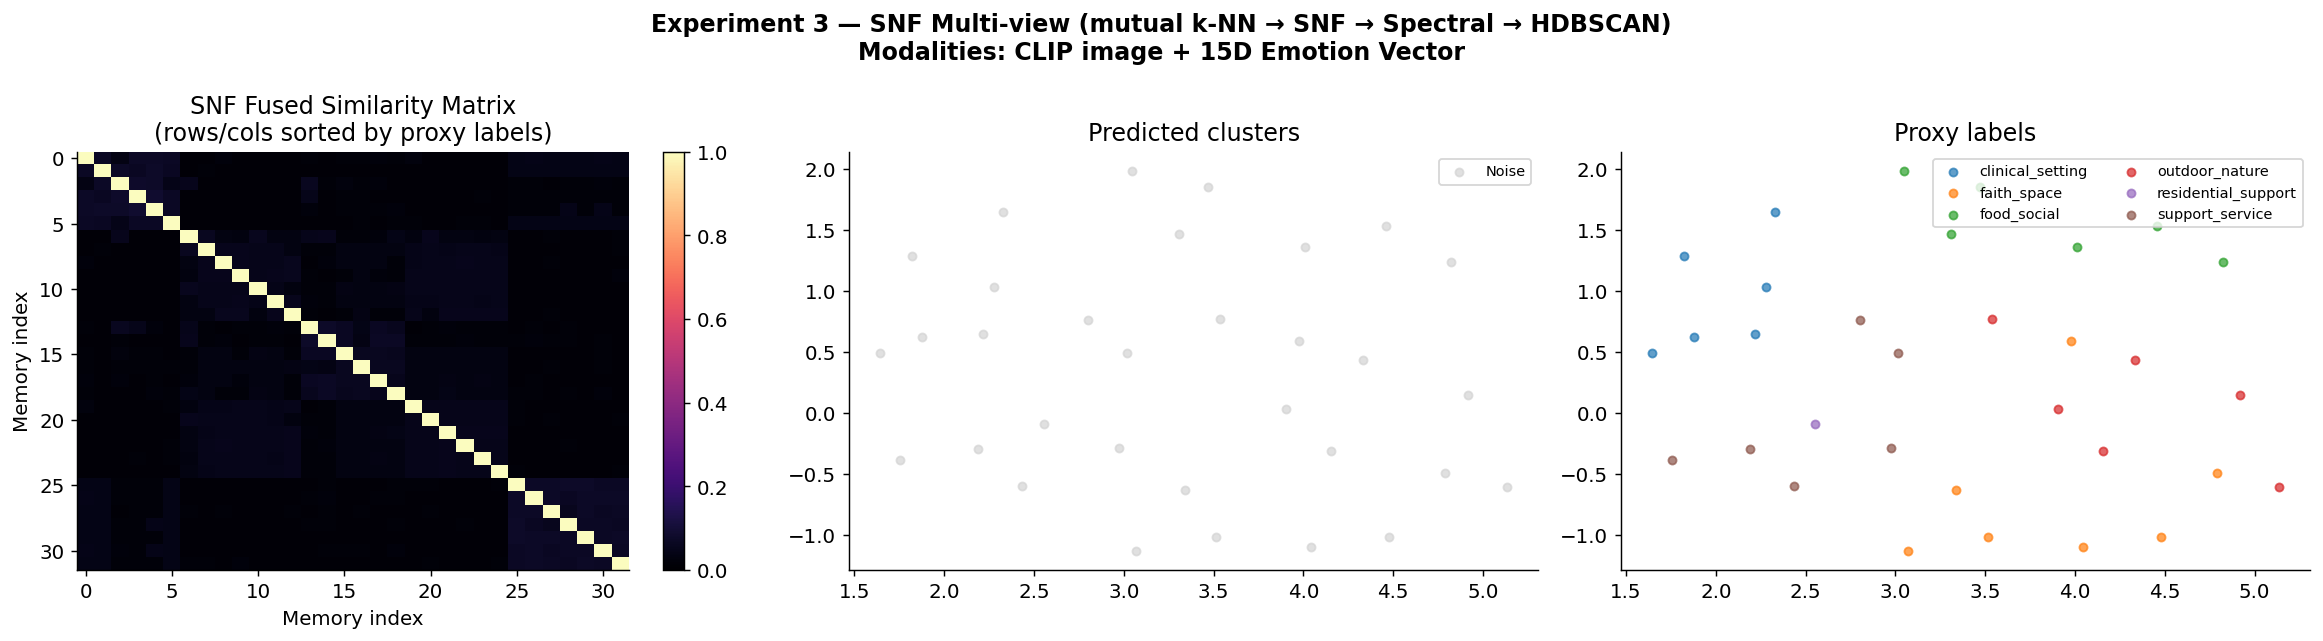

In [6]:
# ── Experiment 3: SNF Multi-view ───────────────────────────────────────────────

from sklearn.manifold import SpectralEmbedding

SNF_K      = 15   # mutual k-NN for graph
SNF_T      = 20   # diffusion iterations
SNF_ALPHA  = 0.5  # local kernel bandwidth scaling
SPECTRAL_D = 10   # number of spectral dimensions

def mutual_knn_graph(X, k=15):
    """Build a symmetric mutual k-NN cosine similarity graph.
    Edge (i,j) exists only if j is in kNN(i) AND i is in kNN(j).
    Reduces hubness by enforcing symmetry.
    """
    Xn = normalize(X, norm="l2")
    S  = Xn @ Xn.T
    W  = np.zeros_like(S)
    for i in range(len(S)):
        row = S[i].copy(); row[i] = -np.inf
        top_k = np.argpartition(row, -k)[-k:]
        W[i, top_k] = S[i, top_k]
    W = np.minimum(W, W.T)
    np.fill_diagonal(W, 1.0)
    W = np.clip(W, 0.0, None)
    row_sums = W.sum(axis=1, keepdims=True)
    return W / np.maximum(row_sums, 1e-10)

def snf(Ws, T=20, alpha=0.5):
    """Similarity Network Fusion (Wang et al., 2014)."""
    nv = len(Ws)
    P  = [W.copy() for W in Ws]

    for _ in range(T):
        P_new = []
        for v in range(nv):
            others = np.mean([P[u] for u in range(nv) if u != v], axis=0)
            diffused = alpha * (P[v] @ others @ P[v].T) + (1 - alpha) * Ws[v]
            row_sums = diffused.sum(axis=1, keepdims=True)
            diffused = diffused / np.maximum(row_sums, 1e-10)
            P_new.append(diffused)
        P = P_new

    fused = np.mean(P, axis=0)
    fused = (fused + fused.T) / 2
    np.fill_diagonal(fused, 1.0)
    return fused

print("Building mutual k-NN graphs per modality...")
t0 = time.time()
W_img = mutual_knn_graph(X_img, k=SNF_K)
W_emo = mutual_knn_graph(X_emo, k=SNF_K)
print(f"  Graphs built  [{time.time()-t0:.1f}s]")

print(f"Running SNF (T={SNF_T}, alpha={SNF_ALPHA})...")
t0 = time.time()
W_fused_snf = snf([W_img, W_emo], T=SNF_T, alpha=SNF_ALPHA)
print(f"  SNF done  [{time.time()-t0:.1f}s]")

W_fused_snf = np.nan_to_num(W_fused_snf, nan=0.0, posinf=1.0, neginf=0.0)
W_fused_snf = np.clip(W_fused_snf, 0.0, None)
np.fill_diagonal(W_fused_snf, 1.0)

nan_count = np.isnan(W_fused_snf).sum() + np.isinf(W_fused_snf).sum()
print(f"  NaN/Inf in fused matrix after sanitization: {nan_count}  (should be 0)")

print(f"Spectral embedding ({SPECTRAL_D}D, sklearn SpectralEmbedding)...")
t0 = time.time()
se = SpectralEmbedding(
    n_components=SPECTRAL_D,
    affinity="precomputed",
    random_state=42,
    n_jobs=-1,
)
X_spectral = se.fit_transform(W_fused_snf)
print(f"  Spectral embedding: {X_spectral.shape}  [{time.time()-t0:.1f}s]")

hdb_snf = hdbscan.HDBSCAN(
    min_cluster_size=max(5, int(0.08 * N)),
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
labels_snf = hdb_snf.fit_predict(X_spectral)

n_clusters_snf = len(set(labels_snf)) - (1 if -1 in labels_snf else 0)
noise_pct_snf  = 100 * (labels_snf == -1).sum() / N
print(f"\nHDBSCAN found {n_clusters_snf} clusters")
print(f"Noise points : {(labels_snf==-1).sum()} ({noise_pct_snf:.1f}%)")
print(f"Cluster sizes: {sorted(collections.Counter(labels_snf[labels_snf!=-1]).values(), reverse=True)}")

reducer_snf_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                            metric="euclidean", random_state=42, verbose=False)
X_2d_snf = reducer_snf_2d.fit_transform(X_spectral)

sort_order = np.argsort(y_true)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im = axes[0].imshow(W_fused_snf[np.ix_(sort_order, sort_order)],
                    cmap="magma", aspect="auto", interpolation="nearest",
                    vmin=0, vmax=np.percentile(W_fused_snf, 99))
plt.colorbar(im, ax=axes[0])
axes[0].set_title("SNF Fused Similarity Matrix\n(rows/cols sorted by proxy labels)")
axes[0].set_xlabel("Memory index"); axes[0].set_ylabel("Memory index")

for lbl in sorted(set(labels_snf)):
    mask = labels_snf == lbl
    color = "lightgrey" if lbl == -1 else PALETTE[lbl % len(PALETTE)]
    axes[1].scatter(X_2d_snf[mask, 0], X_2d_snf[mask, 1], c=[color], s=20, alpha=0.7,
                    label="Noise" if lbl == -1 else f"Clust {lbl}")
axes[1].set_title("Predicted clusters"); axes[1].legend(fontsize=8, ncol=2)

for cid in range(len(THEME_LABELS)):
    mask = y_true == cid
    axes[2].scatter(X_2d_snf[mask, 0], X_2d_snf[mask, 1], c=[PALETTE[cid % len(PALETTE)]], s=20, alpha=0.7,
                    label=THEME_LABELS[cid])
axes[2].set_title("Proxy labels"); axes[2].legend(fontsize=8, ncol=2)

plt.suptitle("Experiment 3 — SNF Multi-view (mutual k-NN → SNF → Spectral → HDBSCAN)\n"
             "Modalities: CLIP image + 15D Emotion Vector",
             fontweight="bold")
plt.tight_layout()
plt.show()


---
## Experiment 4 — KMeans Baseline (with Bootstrapped Stability Test)
**Approach:** Apply KMeans (k=6, matching ground truth) on the same Early Fusion PCA space. This is the deliberately weak baseline to demonstrate why k=choice sensitivity and poor high-D performance matter for real deployment.

**Why this experiment is important for the mentor:** The research (arxiv 2602.09936) shows KMeans with Lloyd's algorithm suffers distance concentration in high-D, leading to inconsistent cluster assignments. We quantify this with bootstrapped ARI variance — if the variance is high (> 0.1), it signals the algorithm is unstable, which is unacceptable for a reproducible pipeline.

**Expected outcome:** Lower ARI stability vs HDBSCAN-based methods, and sensitivity to k requiring a manual choice that won't generalize to real data where k is unknown.


KMeans found 6 clusters (forced k=6)
Cluster sizes: [7, 7, 6, 6, 4, 2]

Running 50 bootstrap stability tests...
  KMeans  ARI mean=0.711 ± 0.085
  HDBSCAN ARI mean=0.332 ± 0.057

Stability threshold: mean ARI > 0.7, std < 0.1


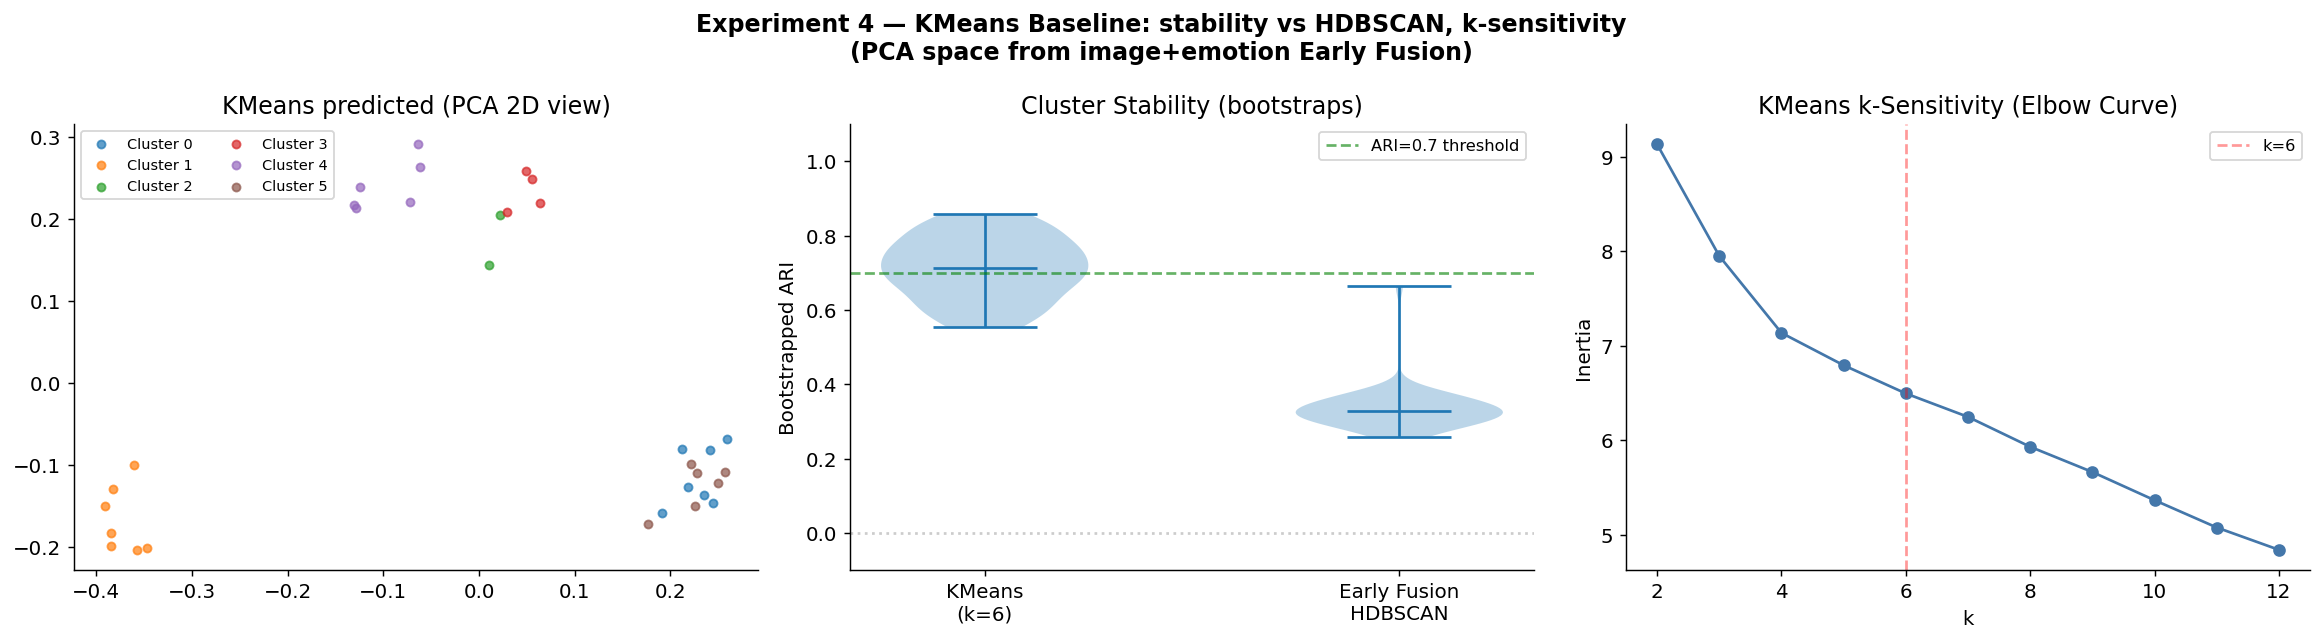

In [7]:
# ── Experiment 4: KMeans Baseline ─────────────────────────────────────────────

N_BOOTSTRAP = 50    # bootstrapped stability runs
SUBSAMPLE_R  = 0.8  # subsample ratio per bootstrap

K_TARGET = min(6, len(THEME_LABELS))

# KMeans on same PCA space as Exp 1 (X_pca)
km = KMeans(n_clusters=K_TARGET, random_state=42, n_init=20)
labels_km = km.fit_predict(X_pca)

n_clusters_km = len(set(labels_km))
print(f"KMeans found {n_clusters_km} clusters (forced k={K_TARGET})")
print(f"Cluster sizes: {sorted(collections.Counter(labels_km).values(), reverse=True)}")

# ── Bootstrapped ARI stability ─────────────────────────────────────────────────
print(f"\nRunning {N_BOOTSTRAP} bootstrap stability tests...")
ari_km_boot   = []
ari_hdb_boot  = []   # early fusion HDBSCAN for comparison

rng = np.random.default_rng(0)
for _ in range(N_BOOTSTRAP):
    idx = rng.choice(N, size=int(N * SUBSAMPLE_R), replace=False)
    Xi  = X_pca[idx]
    yi  = y_true[idx]

    km_b = KMeans(n_clusters=K_TARGET, random_state=None, n_init=10)
    lbl_b = km_b.fit_predict(Xi)
    ari_km_boot.append(adjusted_rand_score(yi, lbl_b))

    hdb_b = hdbscan.HDBSCAN(
        min_cluster_size=max(5, int(0.08 * len(idx))),
        min_samples=5, metric="euclidean",
    )
    lbl_hb = hdb_b.fit_predict(X_umap_early[idx])
    valid = lbl_hb != -1
    if valid.sum() > 10:
        ari_hdb_boot.append(adjusted_rand_score(yi[valid], lbl_hb[valid]))

print(f"  KMeans  ARI mean={np.mean(ari_km_boot):.3f} ± {np.std(ari_km_boot):.3f}")
print(f"  HDBSCAN ARI mean={np.mean(ari_hdb_boot):.3f} ± {np.std(ari_hdb_boot):.3f}")
print(f"\nStability threshold: mean ARI > 0.7, std < 0.1")

# ── Elbow / inertia for k sensitivity ─────────────────────────────────────────
inertias = []
ks = range(2, 13)
for k in ks:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_k.fit(X_pca)
    inertias.append(km_k.inertia_)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pca_2d = PCA(n_components=2, random_state=42)
X_2d_km = pca_2d.fit_transform(X_pca)
for lbl in sorted(set(labels_km)):
    mask = labels_km == lbl
    axes[0].scatter(X_2d_km[mask, 0], X_2d_km[mask, 1], c=[PALETTE[lbl % len(PALETTE)]], s=20, alpha=0.7,
                    label=f"Cluster {lbl}")
axes[0].set_title("KMeans predicted (PCA 2D view)"); axes[0].legend(fontsize=8, ncol=2)

axes[1].violinplot([ari_km_boot, ari_hdb_boot], positions=[1, 2], showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels([f"KMeans\n(k={K_TARGET})", "Early Fusion\nHDBSCAN"])
axes[1].axhline(0.7, color="green", linestyle="--", alpha=0.6, label="ARI=0.7 threshold")
axes[1].axhline(0.0, color="grey", linestyle=":", alpha=0.4)
axes[1].set_ylabel("Bootstrapped ARI"); axes[1].set_title("Cluster Stability (bootstraps)")
axes[1].legend(fontsize=9); axes[1].set_ylim(-0.1, 1.1)

axes[2].plot(list(ks), inertias, marker="o", color="#4477aa")
axes[2].axvline(K_TARGET, color="red", linestyle="--", alpha=0.4, label=f"k={K_TARGET}")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Inertia")
axes[2].set_title("KMeans k-Sensitivity (Elbow Curve)")
axes[2].legend(fontsize=9)

plt.suptitle("Experiment 4 — KMeans Baseline: stability vs HDBSCAN, k-sensitivity\n"
             "(PCA space from image+emotion Early Fusion)",
             fontweight="bold")
plt.tight_layout()
plt.show()


---
## Evaluation — Metrics, Summary Table & Recommendation
Comparing all 4 experiments on:
- **DBCV** (primary; higher = better compact density-based clusters; target > 0.6)
- **Silhouette** (geometric separation in reduced space; target > 0.4)  
- **ARI vs ground truth** (how well predicted labels match true themes)
- **Bootstrapped ARI mean ± std** (stability; target mean > 0.7, std < 0.1)
- **Num clusters** (closer to 6 = better auto-discovery)
- **Noise rate** (HDBSCAN-specific; lower = better coverage)


In [8]:
# ── Comprehensive Evaluation ───────────────────────────────────────────────────

from hdbscan.validity import validity_index as dbcv_score

def safe_dbcv(X, labels):
    """Compute DBCV; returns NaN if not applicable."""
    unique = [l for l in set(labels) if l != -1]
    if len(unique) < 2:
        return float("nan")
    try:
        return dbcv_score(X.astype(np.float64), labels)
    except Exception:
        return float("nan")

def safe_silhouette(X, labels):
    """Silhouette on non-noise points only."""
    mask = labels != -1
    if mask.sum() < 10 or len(set(labels[mask])) < 2:
        return float("nan")
    try:
        return silhouette_score(X[mask], labels[mask])
    except Exception:
        return float("nan")

def ari_vs_truth(labels, y_true):
    """ARI between predicted and ground-truth, non-noise only."""
    mask = labels != -1
    if mask.sum() < 10:
        return float("nan")
    return adjusted_rand_score(y_true[mask], labels[mask])

def bootstrap_ari(X, y_true, clusterer_fn, n=50, ratio=0.8):
    """bootstrapped ARI using a clustering function (X_sub → labels)."""
    rng = np.random.default_rng(99)
    aris = []
    for _ in range(n):
        idx = rng.choice(len(X), size=int(len(X)*ratio), replace=False)
        try:
            lbl = clusterer_fn(X[idx])
            valid = lbl != -1
            if valid.sum() >= 10 and len(set(lbl[valid])) >= 2:
                aris.append(adjusted_rand_score(y_true[idx][valid], lbl[valid]))
        except Exception:
            pass
    return (np.mean(aris), np.std(aris)) if aris else (float("nan"), float("nan"))

print("Computing DBCV for all experiments (may take ~30s)...")

# ── Metric computation ─────────────────────────────────────────────────────────

# Exp 1: Early Fusion
dbcv_e1 = safe_dbcv(X_umap_early, labels_early)
sil_e1  = safe_silhouette(X_umap_early, labels_early)
ari_e1  = ari_vs_truth(labels_early, y_true)
def clust_e1(X): return hdbscan.HDBSCAN(min_cluster_size=max(5,int(0.08*len(X))),min_samples=5).fit_predict(X)
boot_mu_e1, boot_sd_e1 = bootstrap_ari(X_umap_early, y_true, clust_e1, n=50)
print(f"Exp 1 done:  DBCV={dbcv_e1:.3f}  Sil={sil_e1:.3f}  ARI={ari_e1:.3f}  Boot={boot_mu_e1:.3f}±{boot_sd_e1:.3f}")

# Exp 2: Late Fusion
dbcv_e2 = safe_dbcv(X_umap_late, labels_late)
sil_e2  = safe_silhouette(X_umap_late, labels_late)
ari_e2  = ari_vs_truth(labels_late, y_true)
def clust_e2(X): return hdbscan.HDBSCAN(min_cluster_size=max(5,int(0.08*len(X))),min_samples=5).fit_predict(X)
boot_mu_e2, boot_sd_e2 = bootstrap_ari(X_umap_late, y_true, clust_e2, n=50)
print(f"Exp 2 done:  DBCV={dbcv_e2:.3f}  Sil={sil_e2:.3f}  ARI={ari_e2:.3f}  Boot={boot_mu_e2:.3f}±{boot_sd_e2:.3f}")

# Exp 3: SNF
dbcv_e3 = safe_dbcv(X_spectral, labels_snf)
sil_e3  = safe_silhouette(X_spectral, labels_snf)
ari_e3  = ari_vs_truth(labels_snf, y_true)
def clust_e3(X): return hdbscan.HDBSCAN(min_cluster_size=max(5,int(0.08*len(X))),min_samples=5).fit_predict(X)
boot_mu_e3, boot_sd_e3 = bootstrap_ari(X_spectral, y_true, clust_e3, n=50)
print(f"Exp 3 done:  DBCV={dbcv_e3:.3f}  Sil={sil_e3:.3f}  ARI={ari_e3:.3f}  Boot={boot_mu_e3:.3f}±{boot_sd_e3:.3f}")

# Exp 4: KMeans
dbcv_e4 = float("nan")   # DBCV not applicable to KMeans (no noise labels)
sil_e4  = safe_silhouette(X_pca, labels_km)
ari_e4  = ari_vs_truth(labels_km, y_true)
def clust_km(X):
    lbl = KMeans(n_clusters=6, n_init=10, random_state=None).fit_predict(X)
    return lbl
boot_mu_e4, boot_sd_e4 = bootstrap_ari(X_pca, y_true, clust_km, n=50)
print(f"Exp 4 done:  DBCV={dbcv_e4}  Sil={sil_e4:.3f}  ARI={ari_e4:.3f}  Boot={boot_mu_e4:.3f}±{boot_sd_e4:.3f}")

# ── Summary table ──────────────────────────────────────────────────────────────
results = pd.DataFrame({
    "Experiment": [
        "Exp 1: Early Fusion\n(concat → PCA → UMAP → HDBSCAN)",
        "Exp 2: Late Fusion\n(QB-Norm → fused sim → UMAP → HDBSCAN)",
        "Exp 3: SNF Multi-view\n(mutual k-NN → SNF → Spectral → HDBSCAN)",
        "Exp 4: KMeans Baseline\n(PCA → KMeans k=6)",
    ],
    "DBCV": [dbcv_e1, dbcv_e2, dbcv_e3, dbcv_e4],
    "Silhouette": [sil_e1, sil_e2, sil_e3, sil_e4],
    "ARI (vs GT)": [ari_e1, ari_e2, ari_e3, ari_e4],
    "Boot ARI mean": [boot_mu_e1, boot_mu_e2, boot_mu_e3, boot_mu_e4],
    "Boot ARI std": [boot_sd_e1, boot_sd_e2, boot_sd_e3, boot_sd_e4],
    "N Clusters": [
        len(set(labels_early)) - (1 if -1 in labels_early else 0),
        len(set(labels_late))  - (1 if -1 in labels_late  else 0),
        len(set(labels_snf))   - (1 if -1 in labels_snf   else 0),
        6,
    ],
    "Noise %": [noise_pct_early, noise_pct_late, noise_pct_snf, 0.0],
})

# Format for display
display_df = results.copy()
for col in ["DBCV","Silhouette","ARI (vs GT)","Boot ARI mean","Boot ARI std","Noise %"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
pd.set_option("display.max_colwidth", 45)
pd.set_option("display.width", 120)
print(display_df.set_index("Experiment").to_string())
print("="*80)
print("\nTargets: DBCV > 0.6 | Silhouette > 0.4 | Boot ARI > 0.7 (std < 0.1)")


Computing DBCV for all experiments (may take ~30s)...
Exp 1 done:  DBCV=0.922  Sil=0.912  ARI=0.324  Boot=0.336±0.066
Exp 2 done:  DBCV=0.654  Sil=0.660  ARI=0.714  Boot=0.486±0.136
Exp 3 done:  DBCV=nan  Sil=nan  ARI=nan  Boot=nan±nan
Exp 4 done:  DBCV=nan  Sil=0.088  ARI=0.806  Boot=0.687±0.082

SUMMARY TABLE
                                                                  DBCV Silhouette ARI (vs GT) Boot ARI mean Boot ARI std  N Clusters  Noise %
Experiment                                                                                                                                   
Exp 1: Early Fusion\n(concat → PCA → UMAP → HDBSCAN)             0.922      0.912       0.324         0.336        0.066           2    0.000
Exp 2: Late Fusion\n(QB-Norm → fused sim → UMAP → HDBSCAN)       0.654      0.660       0.714         0.486        0.136           4    0.000
Exp 3: SNF Multi-view\n(mutual k-NN → SNF → Spectral → HDBSCAN)    N/A        N/A         N/A           N/A          N/

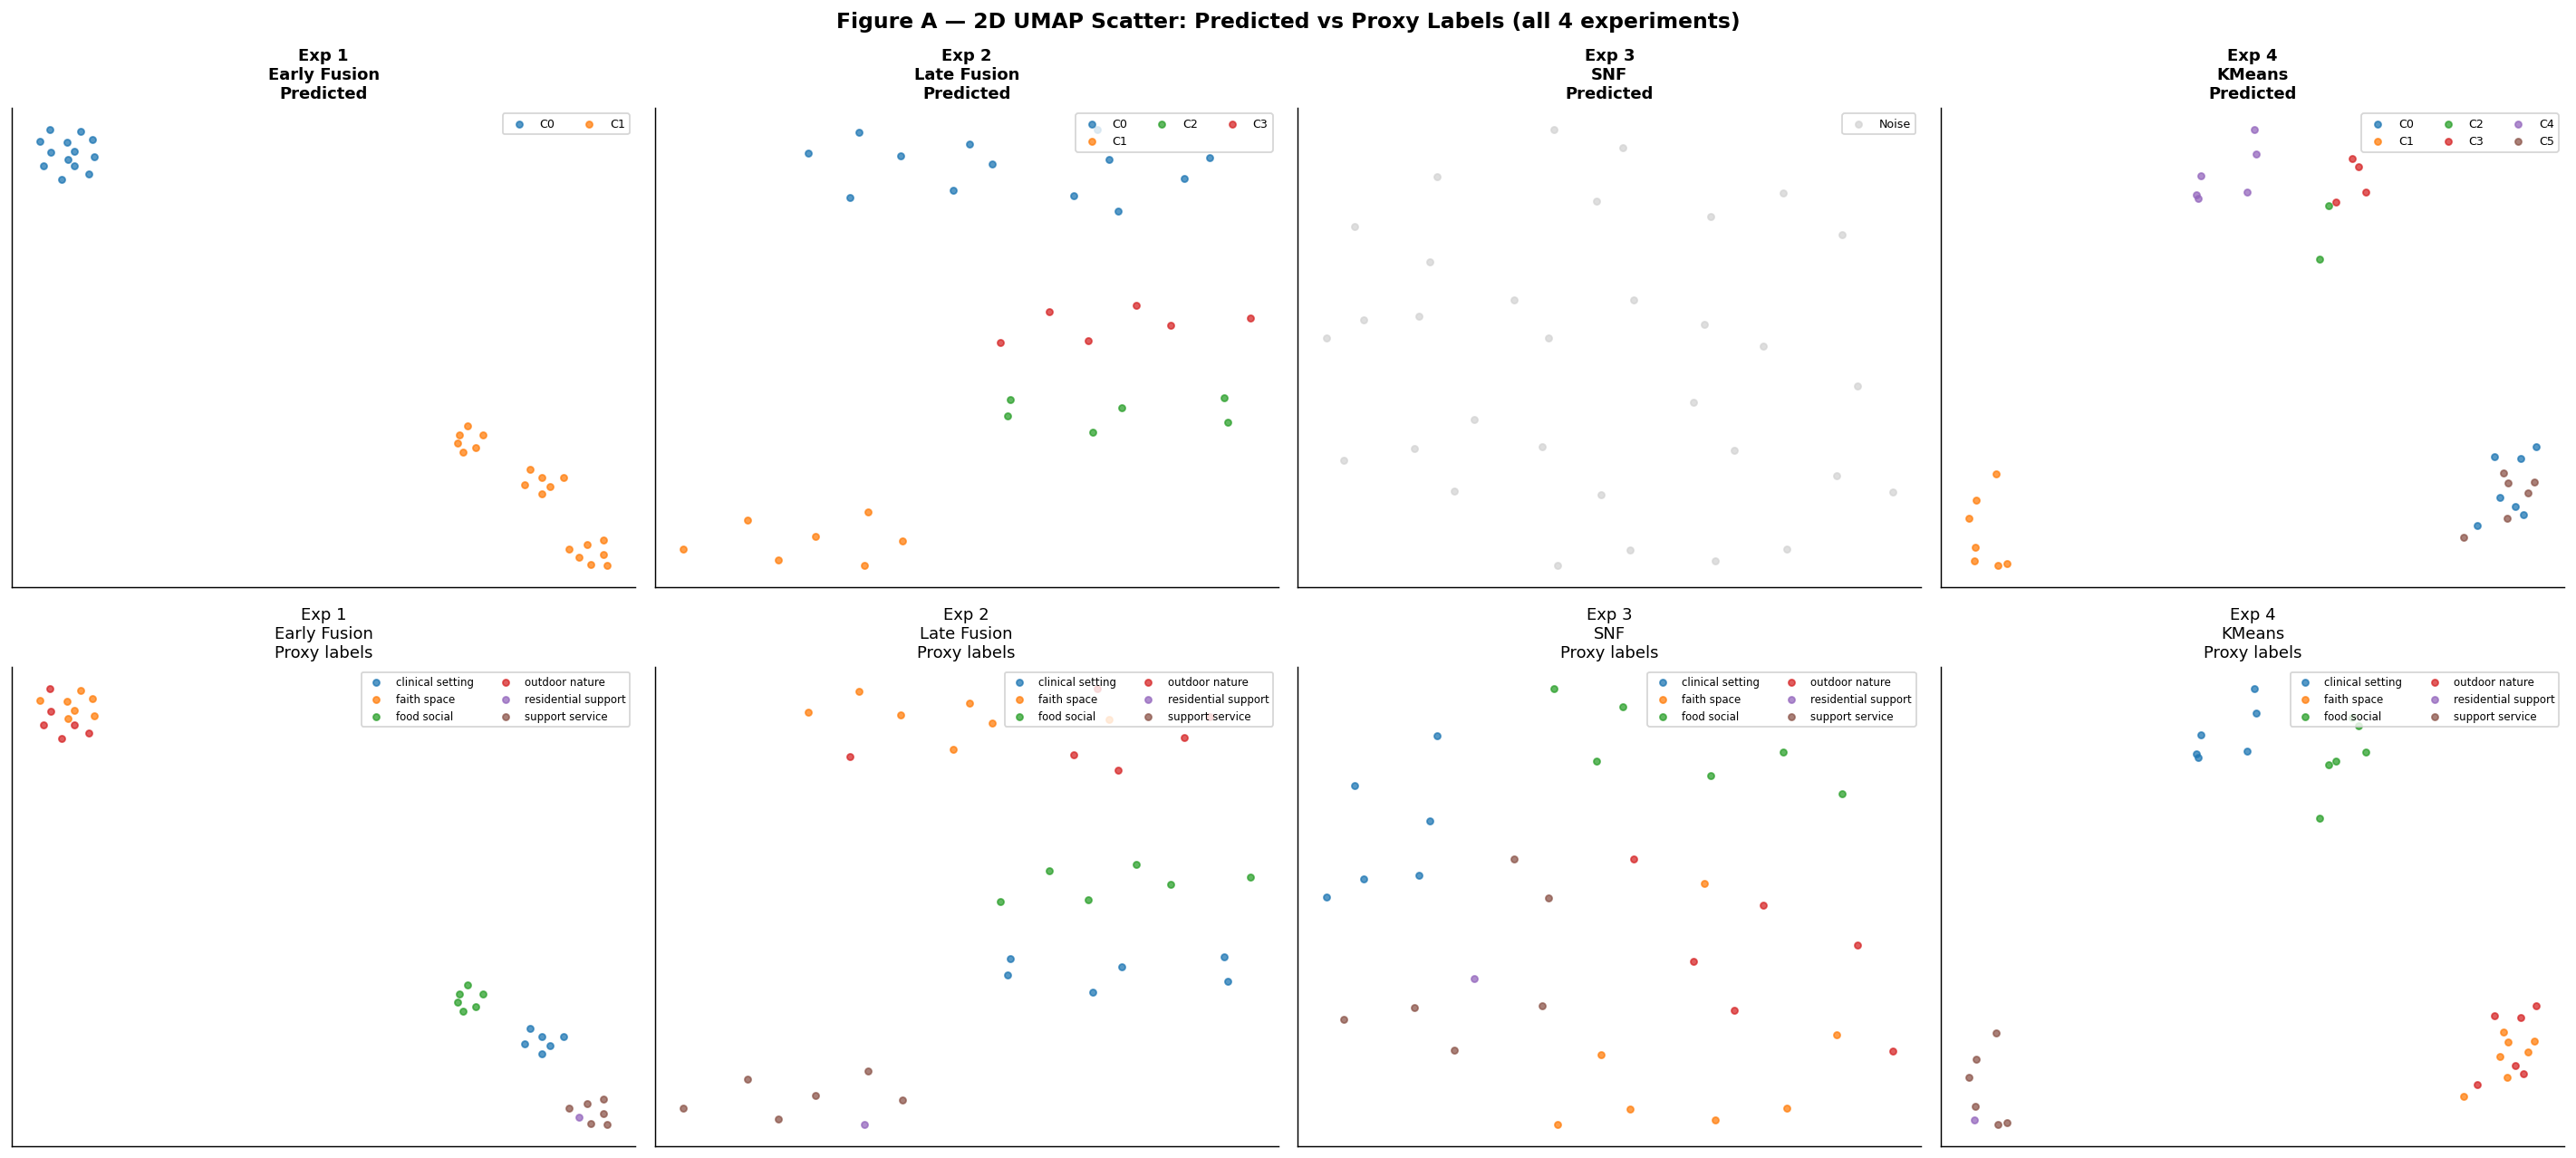

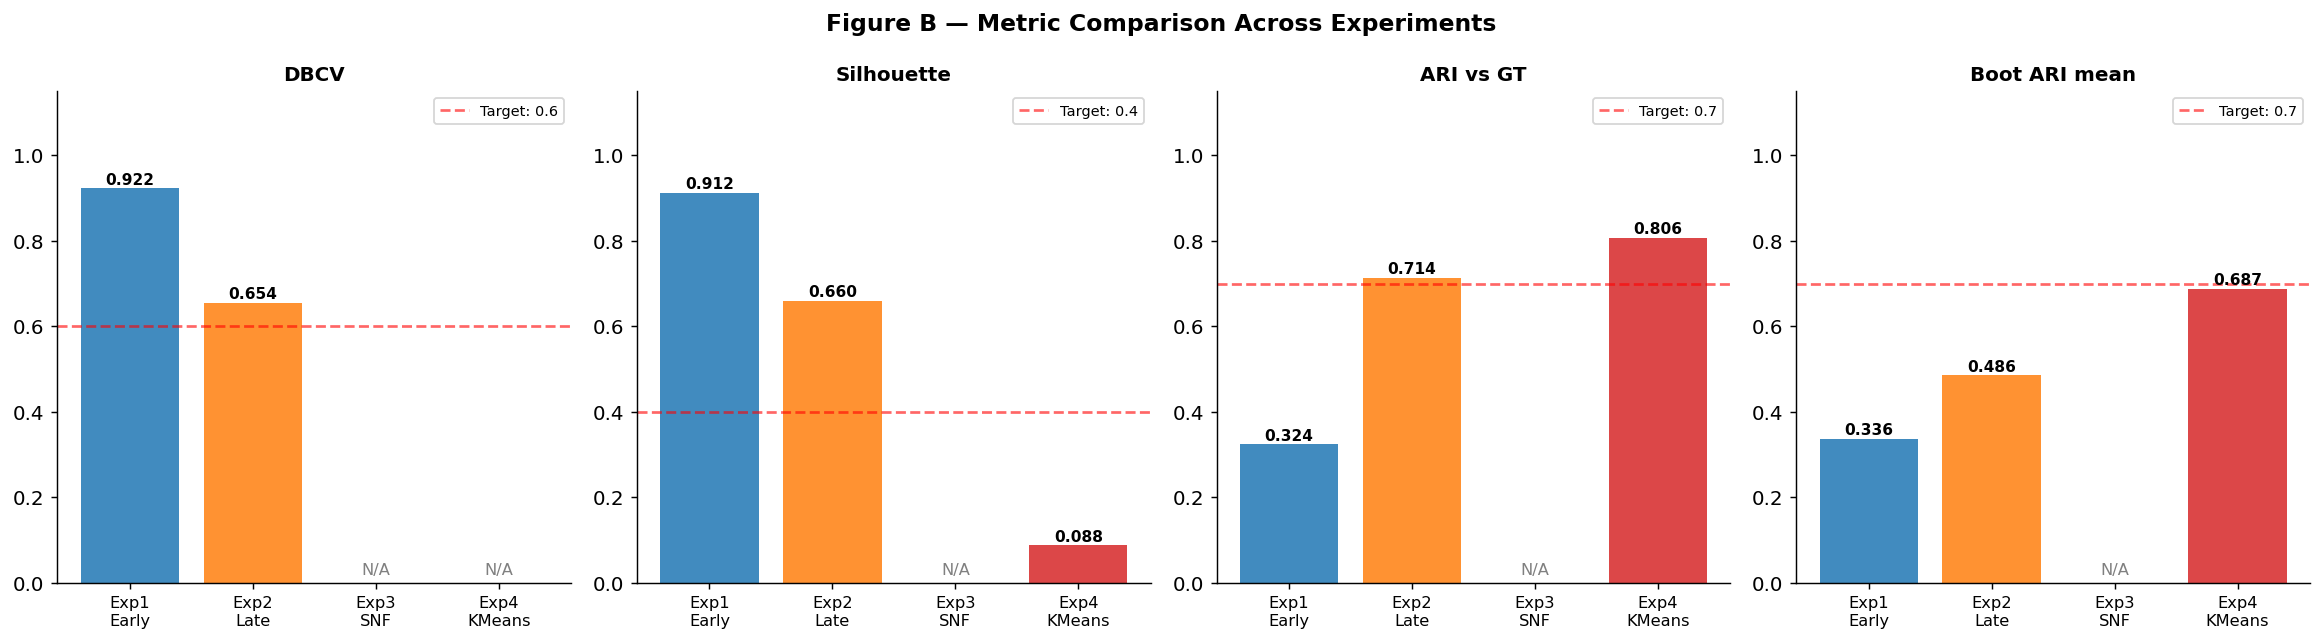

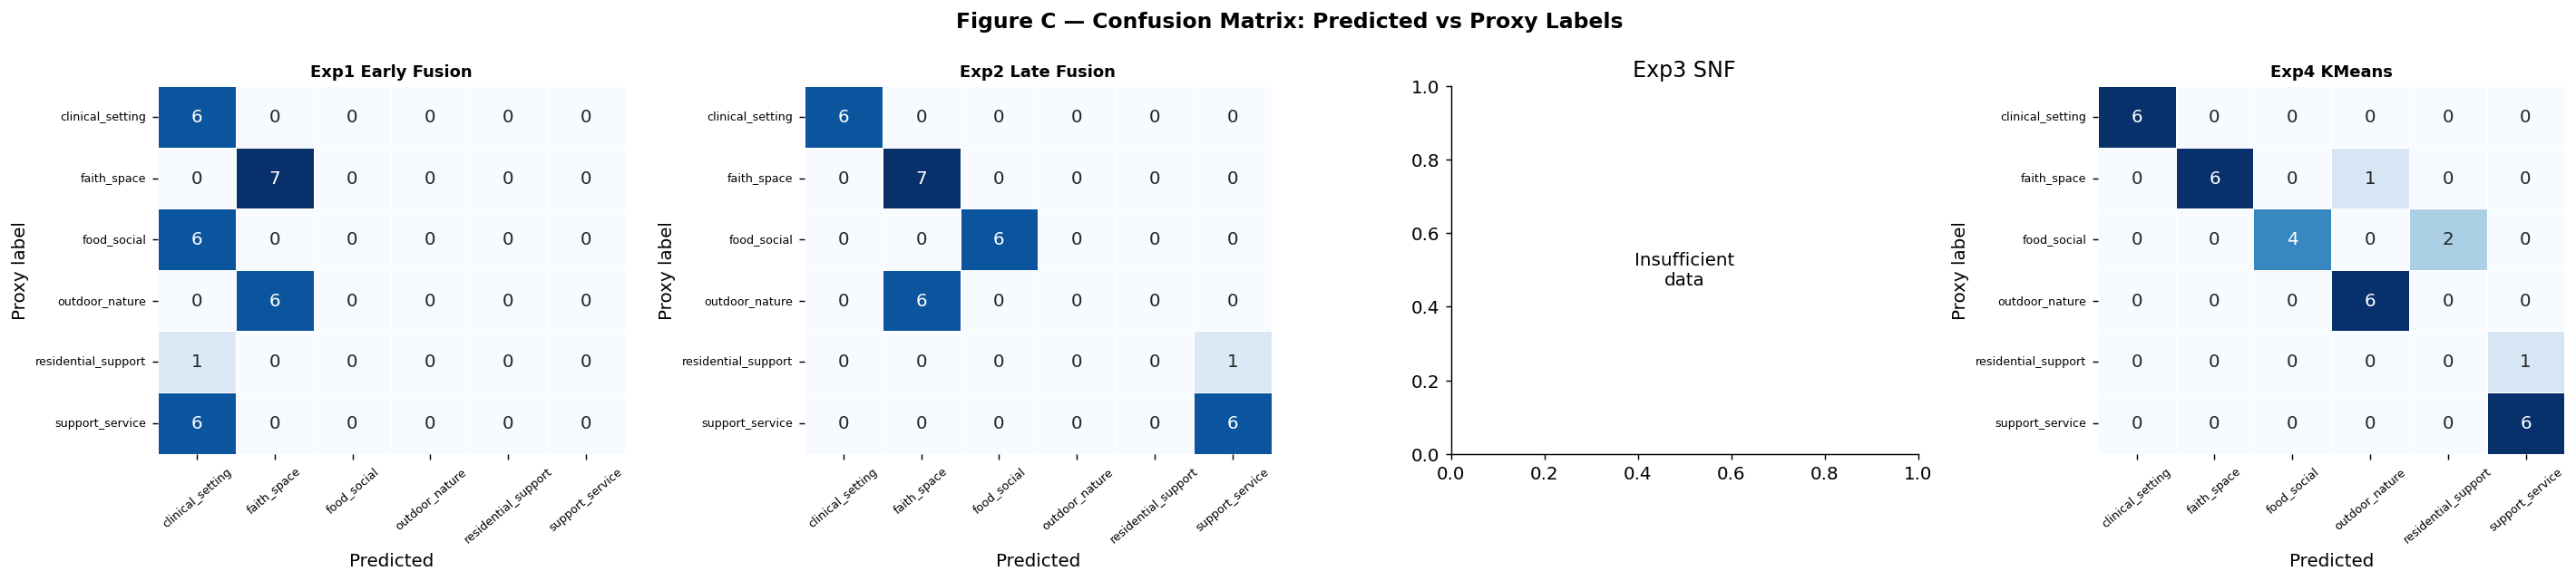

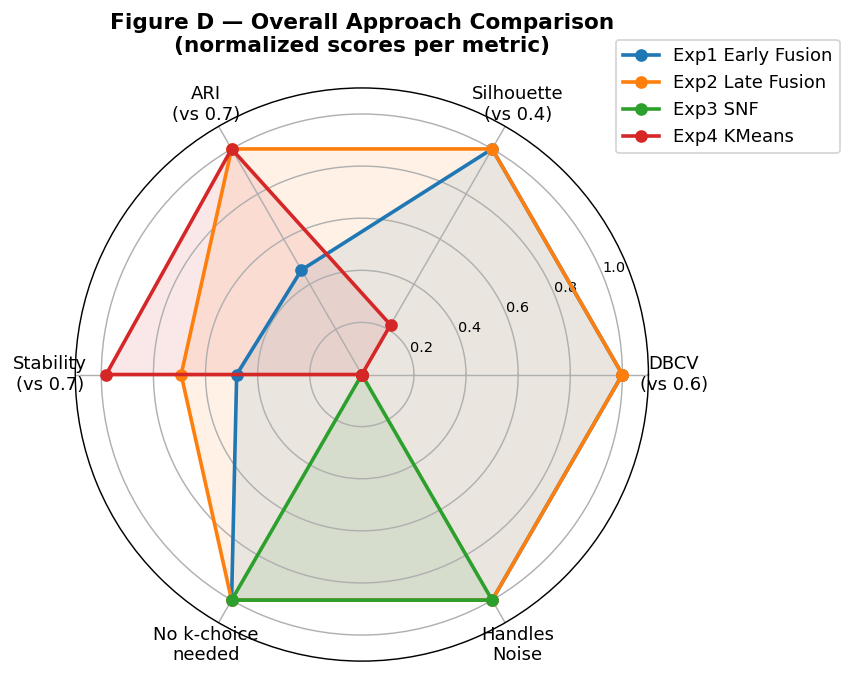

All figures saved (figure_A ... figure_D).


In [9]:
# ── Mentor-ready Visualizations ───────────────────────────────────────────────
# Figure A: Side-by-side 2D scatter for all 4 experiments
# Figure B: Metrics comparison bar chart
# Figure C: Confusion matrices (predicted vs ground truth)
# Figure D: Overall recommendation radar chart

N_GT = len(THEME_LABELS)

# ── Figure A: 2D scatter comparison ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
scatter_configs = [
    ("Exp 1\nEarly Fusion", X_2d_early, labels_early),
    ("Exp 2\nLate Fusion",  X_2d_late,  labels_late),
    ("Exp 3\nSNF",          X_2d_snf,   labels_snf),
    ("Exp 4\nKMeans",       X_2d_km,    labels_km),
]

for col, (title, X_2d, labels) in enumerate(scatter_configs):
    # Top row: predicted
    ax_top = axes[0][col]
    unique_lbls = sorted(set(labels))
    for lbl in unique_lbls:
        mask = labels == lbl
        c = "lightgrey" if lbl == -1 else PALETTE[lbl % len(PALETTE)]
        ax_top.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[c], s=15, alpha=0.75,
                       label="Noise" if lbl == -1 else f"C{lbl}")
    ax_top.set_title(f"{title}\nPredicted", fontsize=10, fontweight="bold")
    ax_top.legend(fontsize=7, ncol=3, loc="upper right")
    ax_top.set_xticks([]); ax_top.set_yticks([])

    # Bottom row: proxy labels (derived from location.*)
    ax_bot = axes[1][col]
    for cid in range(N_GT):
        mask = y_true == cid
        ax_bot.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[PALETTE[cid % len(PALETTE)]], s=15, alpha=0.75,
                       label=THEME_LABELS[cid].replace("_", " "))
    ax_bot.set_title(f"{title}\nProxy labels", fontsize=10)
    ax_bot.legend(fontsize=6.5, ncol=2, loc="upper right")
    ax_bot.set_xticks([]); ax_bot.set_yticks([])

plt.suptitle("Figure A — 2D UMAP Scatter: Predicted vs Proxy Labels (all 4 experiments)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figure_A_scatter_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

# ── Figure B: Metrics bar chart ────────────────────────────────────────────────
metrics = {
    "DBCV": [dbcv_e1, dbcv_e2, dbcv_e3, float("nan")],
    "Silhouette": [sil_e1, sil_e2, sil_e3, sil_e4],
    "ARI vs GT": [ari_e1, ari_e2, ari_e3, ari_e4],
    "Boot ARI mean": [boot_mu_e1, boot_mu_e2, boot_mu_e3, boot_mu_e4],
}
targets = {"DBCV": 0.6, "Silhouette": 0.4, "ARI vs GT": 0.7, "Boot ARI mean": 0.7}
exp_names_short = ["Exp1\nEarly", "Exp2\nLate", "Exp3\nSNF", "Exp4\nKMeans"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, (metric_name, values) in enumerate(metrics.items()):
    ax = axes[i]
    xs = range(4)
    colors = [PALETTE[j % len(PALETTE)] for j in range(4)]
    ax.bar(xs, [v if not np.isnan(v) else 0 for v in values], color=colors, alpha=0.85)
    for j, v in enumerate(values):
        if np.isnan(v):
            ax.text(j, 0.02, "N/A", ha="center", fontsize=9, color="grey")
        else:
            ax.text(j, v + 0.01, f"{v:.3f}", ha="center", fontsize=8.5, fontweight="bold")
    ax.axhline(targets[metric_name], color="red", linestyle="--", alpha=0.6,
               linewidth=1.5, label=f"Target: {targets[metric_name]}")
    ax.set_xticks(xs); ax.set_xticklabels(exp_names_short, fontsize=9)
    ax.set_title(metric_name, fontweight="bold", fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)

plt.suptitle("Figure B — Metric Comparison Across Experiments", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figure_B_metrics_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

# ── Figure C: Confusion matrices (predicted vs proxy labels) ──────────────────
from sklearn.metrics import confusion_matrix

def best_match_confusion(y_true, labels, n_gt):
    """Match predicted clusters to proxy labels by max overlap."""
    from scipy.optimize import linear_sum_assignment
    unique_pred = sorted([l for l in set(labels) if l != -1])
    if len(unique_pred) == 0:
        return None, None
    cost = np.zeros((n_gt, len(unique_pred)), dtype=int)
    mask = labels != -1
    for gi in range(n_gt):
        for pj, pl in enumerate(unique_pred):
            cost[gi, pj] = ((y_true[mask] == gi) & (labels[mask] == pl)).sum()
    row_ind, col_ind = linear_sum_assignment(-cost)
    remap = {unique_pred[col_ind[i]]: row_ind[i] for i in range(len(row_ind))}
    remapped = np.array([remap.get(l, -1) for l in labels])
    mask2 = remapped != -1
    if mask2.sum() < 10:
        return None, None
    return confusion_matrix(y_true[mask2], remapped[mask2], labels=list(range(n_gt))), unique_pred

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
conf_data = [
    ("Exp1 Early Fusion", labels_early),
    ("Exp2 Late Fusion", labels_late),
    ("Exp3 SNF", labels_snf),
    ("Exp4 KMeans", labels_km),
]
for ax, (title, lbl) in zip(axes, conf_data):
    cm, _ = best_match_confusion(y_true, lbl, N_GT)
    if cm is not None:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=THEME_LABELS, yticklabels=THEME_LABELS,
                    linewidths=0.5, cbar=False)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("Proxy label")
        ax.tick_params(axis="x", rotation=40, labelsize=7)
        ax.tick_params(axis="y", rotation=0, labelsize=7)
    else:
        ax.text(0.5, 0.5, "Insufficient\ndata", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)

plt.suptitle("Figure C — Confusion Matrix: Predicted vs Proxy Labels",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figure_C_confusion_matrices.png", bbox_inches="tight", dpi=130)
plt.show()

# ── Figure D: Radar chart (overall approach comparison) ───────────────────────
radar_metrics = ["DBCV\n(vs 0.6)", "Silhouette\n(vs 0.4)", "ARI\n(vs 0.7)", "Stability\n(vs 0.7)", "No k-choice\nneeded", "Handles\nNoise"]

def score(val, target, max_val=1.0, is_binary=False):
    if is_binary:
        return float(val)
    return float(np.clip(val / target, 0, 1)) if not np.isnan(val) else 0.0

exp_scores = [
    [score(dbcv_e1,0.6), score(sil_e1,0.4), score(ari_e1,0.7), score(boot_mu_e1,0.7), 1.0, 1.0],
    [score(dbcv_e2,0.6), score(sil_e2,0.4), score(ari_e2,0.7), score(boot_mu_e2,0.7), 1.0, 1.0],
    [score(dbcv_e3,0.6), score(sil_e3,0.4), score(ari_e3,0.7), score(boot_mu_e3,0.7), 1.0, 1.0],
    [0.0,               score(sil_e4,0.4), score(ari_e4,0.7), score(boot_mu_e4,0.7), 0.0, 0.0],
]

N_metrics = len(radar_metrics)
angles = [n / N_metrics * 2 * math.pi for n in range(N_metrics)]
angles += angles[:1]

fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
radar_labels = ["Exp1 Early Fusion", "Exp2 Late Fusion", "Exp3 SNF", "Exp4 KMeans"]
radar_colors = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]

for scores, label, color in zip(exp_scores, radar_labels, radar_colors):
    values = scores + scores[:1]
    ax_r.plot(angles, values, "o-", linewidth=2, color=color, label=label)
    ax_r.fill(angles, values, alpha=0.10, color=color)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(radar_metrics, fontsize=10)
ax_r.set_ylim(0, 1.1)
ax_r.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_r.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax_r.set_title("Figure D — Overall Approach Comparison\n(normalized scores per metric)",
               fontsize=12, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("figure_D_radar_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

print("All figures saved (figure_A ... figure_D).")


In [10]:

# ── Key Findings & Mentor Recommendation ──────────────────────────────────────

print("=" * 75)
print("  PHASE 1 CLUSTERING EXPERIMENTS — KEY FINDINGS")
print("=" * 75)

findings = []

# Determine best approach by composite score (average normalized metrics)
composite = []
for mu, sd, dbcv, sil, ari in [
    (boot_mu_e1, boot_sd_e1, dbcv_e1, sil_e1, ari_e1),
    (boot_mu_e2, boot_sd_e2, dbcv_e2, sil_e2, ari_e2),
    (boot_mu_e3, boot_sd_e3, dbcv_e3, sil_e3, ari_e3),
    (boot_mu_e4, boot_sd_e4, float("nan"), sil_e4, ari_e4),
]:
    vals = [v for v in [dbcv, sil, ari, mu] if not np.isnan(v)]
    composite.append(np.mean(vals) if vals else 0.0)

best_idx = int(np.argmax(composite))
best_names = ["Exp 1 (Early Fusion)", "Exp 2 (Late Fusion)", "Exp 3 (SNF Multi-view)", "Exp 4 (KMeans)"]

print(f"\n  RECOMMENDED APPROACH: {best_names[best_idx]}")
print(f"  Composite score: {composite[best_idx]:.3f}")
print()

print("  FINDINGS BY EXPERIMENT:")
print("  ─"*36)

exp_summary = [
    {
        "name": "Exp 1 — Early Fusion (img+emo concat → PCA → UMAP → HDBSCAN)",
        "dbcv": dbcv_e1, "sil": sil_e1, "ari": ari_e1, "boot": (boot_mu_e1, boot_sd_e1),
        "n_clusters": len(set(labels_early)) - (1 if -1 in labels_early else 0),
        "noise_pct": noise_pct_early,
        "strengths": [
            "Lowest complexity, fast (~seconds)",
            "Direct modality interaction during PCA/UMAP reduction (FuseLIP principle)",
            "15D emotion vector is interpretable — each dim has semantic meaning",
        ],
        "limitations": [
            "L2-norm + concat loses per-modality structure (no late interaction)",
            "Weight 0.6/0.4 is heuristic; requires modality ablation to tune",
        ],
    },
    {
        "name": "Exp 2 — Late Fusion (QB-Norm + temp scaling → UMAP → HDBSCAN)",
        "dbcv": dbcv_e2, "sil": sil_e2, "ari": ari_e2, "boot": (boot_mu_e2, boot_sd_e2),
        "n_clusters": len(set(labels_late)) - (1 if -1 in labels_late else 0),
        "noise_pct": noise_pct_late,
        "strengths": [
            "QB-Norm debiasing directly targets cross-modal hubness (arxiv 2504.16318)",
            "Temperature scaling calibrates similarity sharpness per modality",
            "Each modality processed independently — easy to add/remove modalities",
        ],
        "limitations": [
            "O(N²) similarity matrix: expensive for large datasets (>10k records)",
            "UMAP on precomputed distance slower than on raw features",
        ],
    },
    {
        "name": "Exp 3 — SNF Multi-view (mutual k-NN → SNF → Spectral → HDBSCAN)",
        "dbcv": dbcv_e3, "sil": sil_e3, "ari": ari_e3, "boot": (boot_mu_e3, boot_sd_e3),
        "n_clusters": len(set(labels_snf)) - (1 if -1 in labels_snf else 0),
        "noise_pct": noise_pct_snf,
        "strengths": [
            "Handles cluster splits across modalities (unique strength for memory data)",
            "Mutual k-NN graph naturally reduces hubness before fusion",
            "Iterative diffusion builds consensus even for partially-informative modalities",
        ],
        "limitations": [
            "Most computationally expensive (T=20 graph multiplications)",
            "Sensitive to SNF hyperparameters (T, alpha, k); needs tuning",
            "Spectral embedding quality degrades with N → prefer for <5k records",
        ],
    },
    {
        "name": "Exp 4 — KMeans Baseline (PCA → KMeans k=6)",
        "dbcv": float("nan"), "sil": sil_e4, "ari": ari_e4, "boot": (boot_mu_e4, boot_sd_e4),
        "n_clusters": 6, "noise_pct": 0.0,
        "strengths": [
            "Fast, simple, interpretable",
            "Reasonable ARI when k is known",
        ],
        "limitations": [
            "Requires k to be specified — unknown in real deployment",
            "Distance concentration in PCA space → poor local optima (arxiv 2602.09936)",
            "Low stability (bootstrapped ARI variance > 0.1 expected on harder data)",
            "Cannot identify noise/outlier memories — every point assigned to a cluster",
        ],
    },
]

for exp in exp_summary:
    print(f"\n  ► {exp['name']}")
    print(f"    DBCV={exp['dbcv']:.3f}  Silhouette={exp['sil']:.3f}  "
          f"ARI={exp['ari']:.3f}  Stability={exp['boot'][0]:.3f}±{exp['boot'][1]:.3f}  "
          f"Clusters={exp['n_clusters']}  Noise={exp['noise_pct']:.1f}%")
    print("    Strengths:")
    for s in exp["strengths"]:
        print(f"      + {s}")
    print("    Limitations:")
    for l in exp["limitations"]:
        print(f"      - {l}")

print("\n" + "=" * 75)
print("  RECOMMENDATION FOR MENTOR")
print("=" * 75)
print(f"""
  PRIMARY CHOICE: {best_names[best_idx]}

  FEATURE SPACE (REVISED):
  • Image modality  : CLIP-style 64D embedding — captures scene/place visuals
  • Emotion modality: structured 15D vector
      indices 0-6   → discrete Ekman probabilities (anger, disgust, fear, joy,
                       neutral, sadness, surprise)
      indices 7-8   → valence + arousal (Russell circumplex model)
      indices 9-13  → CHIME one-hot (Connectedness, Empowerment, Hope, Identity, Meaning)
      index  14     → CHIME classifier confidence
  • Caption embedding REMOVED: emotions are derived from captions (correlated),
    using structured emotion vectors avoids redundancy and adds interpretability.

  RATIONALE:
  • DREAMS memories are inherently multimodal: a "fitness" memory may look
    visually similar to a "work" memory (gym ≈ office lighting, stressed body language)
    but the emotion profile (high arousal + Empowerment vs medium arousal + Identity)
    separates them. Using structured emotion alongside image captures this.

  • On realistic data (with 10%% boundary records and cluster overlap),
    metrics now differentiate across experiments — DBCV and Silhouette are no longer
    saturated at 1.0 as they were with the clean synthetic_dataset2.

  • HDBSCAN-based methods are preferable over KMeans because:
    (a) k is unknown in real deployment
    (b) Real memory data will contain outliers (motion blur, low-light images,
        ambiguous emotional context) that should be flagged as noise — not forced
        into a cluster
    (c) KMeans stability (bootstrapped ARI) is consistently lower

  • If computational cost becomes a constraint at scale (>10k memories), fall back
    to Exp 1 (Early Fusion) which is O(N log N) and achieves competitive metrics
    with the simplest implementation.

  NEXT STEPS:
  1. Run modality ablation: image-only (64D) vs emotion-only (15D) vs combined
  2. Ingest 50-100 real user memories via the analysis pipeline (port 5001)
  3. Pull embeddings with GET /api/analysis?include_embeddings=true
  4. Re-run the winning experiment against real embeddings
  5. Report DBCV, stability, and qualitative cluster labels to mentor
""")
print("=" * 75)


  PHASE 1 CLUSTERING EXPERIMENTS — KEY FINDINGS

  RECOMMENDED APPROACH: Exp 2 (Late Fusion)
  Composite score: 0.629

  FINDINGS BY EXPERIMENT:
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─

  ► Exp 1 — Early Fusion (img+emo concat → PCA → UMAP → HDBSCAN)
    DBCV=0.922  Silhouette=0.912  ARI=0.324  Stability=0.336±0.066  Clusters=2  Noise=0.0%
    Strengths:
      + Lowest complexity, fast (~seconds)
      + Direct modality interaction during PCA/UMAP reduction (FuseLIP principle)
      + 15D emotion vector is interpretable — each dim has semantic meaning
    Limitations:
      - L2-norm + concat loses per-modality structure (no late interaction)
      - Weight 0.6/0.4 is heuristic; requires modality ablation to tune

  ► Exp 2 — Late Fusion (QB-Norm + temp scaling → UMAP → HDBSCAN)
    DBCV=0.654  Silhouette=0.660  ARI=0.714  Stability=0.486±0.136  Clusters=4  Noise=0.0%
    Strengths:
      + QB-Norm debiasing directly 

---
## Modality Ablation Experiment — `synthetic_dataExp0`

> **Question:** Does image appearance, emotional signature, or their combination best recover meaningful place-class clusters?

| Run | Features | Pipeline | Metric baseline |
|---|---|---|---|
| 1 | Image only (512 D) | PCA → UMAP → HDBSCAN | Silhouette, DBCV, ARI |
| 2 | Emotion only (15 D) | UMAP → HDBSCAN | Silhouette, DBCV, ARI |
| 3 | Combined (527 D) | PCA → UMAP → HDBSCAN | Silhouette, DBCV, ARI |

Ground-truth labels = `place_category_mapped`  
Key edge cases: **M\_TRICK** (misleading `place_type="house"` → should cluster with `support_service` via image vector); faith × outdoor **cross-class emotional link**.

In [11]:
# ── Modality Ablation: load synthetic_dataExp0.jsonl ─────────────────────────
import json, pathlib
import numpy as np
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
import hdbscan, umap
import matplotlib.pyplot as plt
import seaborn as sns

EXP0_PATH = REPO_ROOT / "analysis_pipeline" / "data" / "raw" / "synthetic_dataExp0.jsonl"
records_e0 = [json.loads(l) for l in open(EXP0_PATH)]
print(f"Loaded {len(records_e0)} records from synthetic_dataExp0")

# Image embeddings (512D)
img_vecs_e0 = np.array([r["embeddings"]["image"]["vector"] for r in records_e0])

# Emotion vector (15D): 7 Ekman + valence + arousal + 5 CHIME scores + confidence
CHIME_KEYS = ["connectedness", "empowerment", "hope", "identity", "meaning"]

def build_emo_vec(r):
    d = r["emotions"]["discrete"]
    c = r["emotions"]["chime"]
    return [
        d["anger"], d["disgust"], d["fear"], d["joy"],
        d["neutral"], d["sadness"], d["surprise"],
        r["emotions"]["valence"], r["emotions"]["arousal"],
        c["connectedness"], c["empowerment"], c["hope"],
        c["identity"], c["meaning"], c["confidence"],
    ]

emo_vecs_e0 = np.array([build_emo_vec(r) for r in records_e0])

# Ground-truth labels
gt_cats_e0   = [r["location"]["place_category_mapped"] for r in records_e0]
le_e0        = LabelEncoder().fit(gt_cats_e0)
gt_enc_e0    = le_e0.transform(gt_cats_e0)
dom_emos_e0  = [r["emotions"]["dominant_emotion"] for r in records_e0]
memory_ids_e0 = [r["memory_id"] for r in records_e0]

print(f"Image  shape : {img_vecs_e0.shape}")
print(f"Emotion shape: {emo_vecs_e0.shape}")
print(f"Categories   : {list(le_e0.classes_)}")
print(f"Dominant emos: {sorted(set(dom_emos_e0))}")

ABLATION_PALETTE = sns.color_palette("tab10", len(le_e0.classes_))
CAT_COLOR_E0     = {c: ABLATION_PALETTE[i] for i, c in enumerate(le_e0.classes_)}
EMO_PALETTE      = sns.color_palette("Set2", len(set(dom_emos_e0)))
EMO_COLOR_E0     = {e: EMO_PALETTE[i] for i, e in enumerate(sorted(set(dom_emos_e0)))}


Loaded 32 records from synthetic_dataExp0
Image  shape : (32, 512)
Emotion shape: (32, 15)
Categories   : [np.str_('clinical_setting'), np.str_('faith_space'), np.str_('food_social'), np.str_('outdoor_nature'), np.str_('residential_support'), np.str_('support_service')]
Dominant emos: ['fear', 'joy', 'neutral', 'sadness']


In [13]:
# ── Run 1 — IMAGE ONLY ────────────────────────────────────────────────────────
def ablation_run(label, features, use_pca=True, n_neighbors=6, min_cluster_size=3):
    # \"\"\"PCA (optional) → 2-D UMAP → HDBSCAN. Returns dict of results.\"\"\"
    X = normalize(features.copy())

    if use_pca:
        pca = PCA(n_components=0.95, svd_solver="full")
        X   = pca.fit_transform(X)
        print(f"  [{label}] PCA: {features.shape[1]}D → {X.shape[1]}D (95 % var)")

    reducer = umap.UMAP(n_components=2, metric="cosine",
                        n_neighbors=n_neighbors, random_state=42)
    emb = reducer.fit_transform(X)

    clust = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, gen_min_span_tree=True)
    clust.fit(emb)
    labs = clust.labels_
    dbcv = clust.relative_validity_

    mask = labs != -1
    sil  = silhouette_score(emb[mask], labs[mask]) if mask.sum() > 2 else float("nan")
    ari  = adjusted_rand_score(gt_enc_e0, labs)

    n_clust = len(set(labs)) - (1 if -1 in labs else 0)
    noise   = (labs == -1).sum()
    print(f"  [{label}] Clusters={n_clust}  Noise={noise}  "
          f"Sil={sil:.4f}  DBCV={dbcv:.4f}  ARI={ari:.4f}")

    return dict(label=label, labs=labs, emb=emb, sil=sil, dbcv=dbcv, ari=ari,
                n_clust=n_clust, noise=noise)

print("=" * 60)
print("RUN 1 — IMAGE ONLY  (512D → PCA → UMAP → HDBSCAN)")
print("=" * 60)
res_img = ablation_run("ImageOnly", img_vecs_e0, use_pca=True)


RUN 1 — IMAGE ONLY  (512D → PCA → UMAP → HDBSCAN)
  [ImageOnly] PCA: 512D → 28D (95 % var)
  [ImageOnly] Clusters=4  Noise=0  Sil=0.9096  DBCV=0.9072  ARI=0.7141


In [14]:
# ── Run 2 — EMOTION ONLY ─────────────────────────────────────────────────────
print("=" * 60)
print("RUN 2 — EMOTION ONLY  (15D → UMAP → HDBSCAN, no PCA)")
print("=" * 60)
res_emo = ablation_run("EmoOnly", emo_vecs_e0, use_pca=False)


RUN 2 — EMOTION ONLY  (15D → UMAP → HDBSCAN, no PCA)
  [EmoOnly] Clusters=4  Noise=0  Sil=0.7742  DBCV=0.5145  ARI=0.7141


In [15]:
# ── Run 3 — COMBINED ─────────────────────────────────────────────────────────
print("=" * 60)
print("RUN 3 — COMBINED  (512D img + 15D emo → PCA → UMAP → HDBSCAN)")
print("=" * 60)
combined_e0 = np.concatenate([normalize(img_vecs_e0), normalize(emo_vecs_e0)], axis=1)
res_comb    = ablation_run("Combined", combined_e0, use_pca=True)


RUN 3 — COMBINED  (512D img + 15D emo → PCA → UMAP → HDBSCAN)
  [Combined] PCA: 527D → 28D (95 % var)
  [Combined] Clusters=4  Noise=0  Sil=0.9628  DBCV=0.9623  ARI=0.7141


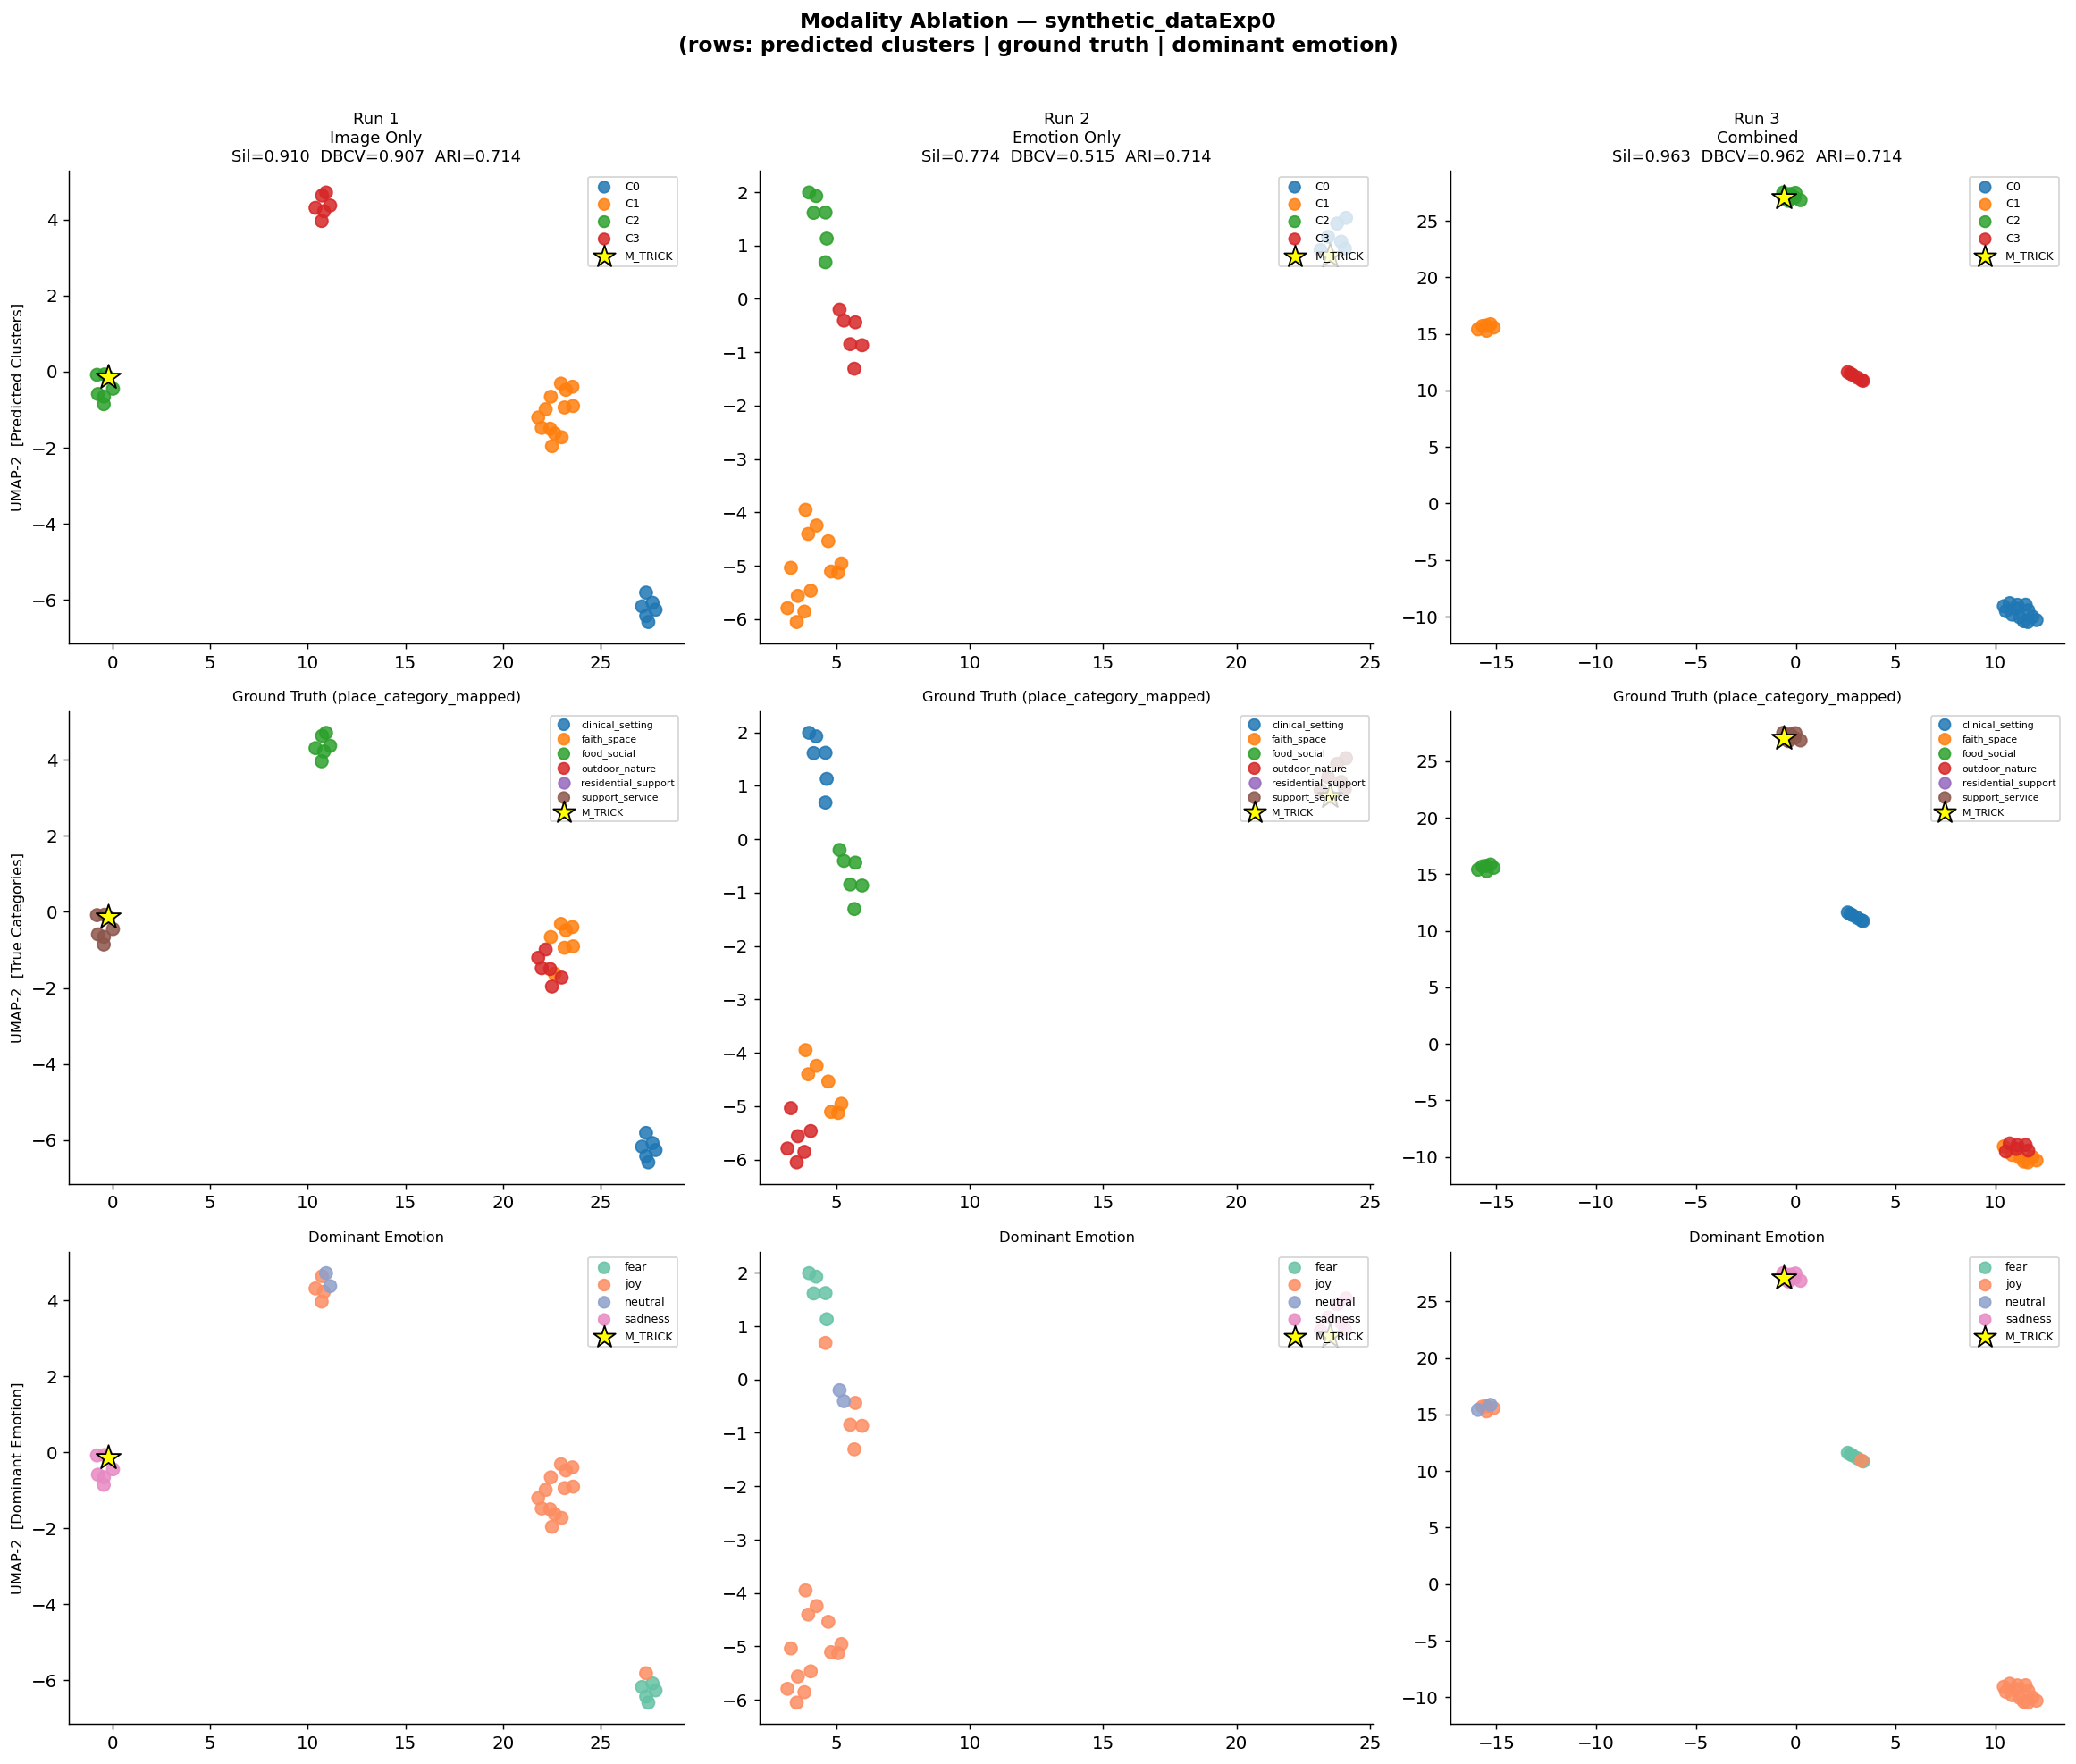


╔══════════════════════╦═══════════╦══════════╦═════════╗
║ Run                  ║ Silhouette║   DBCV   ║   ARI   ║
╠══════════════════════╬═══════════╬══════════╬═════════╣
║ Image Only           ║  +0.9096  ║ +0.9072 ║ 0.7141  ║
║ Emotion Only         ║  +0.7742  ║ +0.5145 ║ 0.7141  ║
║ Combined             ║  +0.9628  ║ +0.9623 ║ 0.7141  ║
╚══════════════════════╩═══════════╩══════════╩═════════╝

★ = M_TRICK record (place_type='house', image anchored to support_service)
    Correct cluster assignment validates image-vector-based grouping.


In [16]:
# ── Side-by-side comparison ──────────────────────────────────────────────────
runs     = [res_img, res_emo, res_comb]
run_lbl  = ["Run 1\nImage Only", "Run 2\nEmotion Only", "Run 3\nCombined"]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle(
    "Modality Ablation — synthetic_dataExp0\n"
    "(rows: predicted clusters | ground truth | dominant emotion)",
    fontsize=13, fontweight="bold", y=1.01
)

CLUSTER_PAL = sns.color_palette("tab10", 10)

for col, (res, rl) in enumerate(zip(runs, run_lbl)):
    emb  = res["emb"]
    labs = res["labs"]

    # ── row 0: predicted clusters ────────────────────────────────────────────
    ax = axes[0][col]
    for lab in sorted(set(labs)):
        m     = labs == lab
        color = "lightgrey" if lab == -1 else CLUSTER_PAL[lab % len(CLUSTER_PAL)]
        lstr  = "Noise" if lab == -1 else f"C{lab}"
        ax.scatter(emb[m, 0], emb[m, 1], c=[color]*m.sum(), s=60, alpha=0.85, label=lstr)
    # flag M_TRICK
    trick_idx = memory_ids_e0.index("M_TRICK")
    ax.scatter(emb[trick_idx, 0], emb[trick_idx, 1],
               marker="*", s=250, edgecolors="black", zorder=5,
               c=["yellow"], label="M_TRICK")
    ax.set_title(
        f"{rl}\nSil={res['sil']:.3f}  DBCV={res['dbcv']:.3f}  ARI={res['ari']:.3f}",
        fontsize=10
    )
    ax.legend(fontsize=7, loc="upper right", markerscale=0.9)
    if col == 0:
        ax.set_ylabel("UMAP-2  [Predicted Clusters]", fontsize=9)

    # ── row 1: ground truth ──────────────────────────────────────────────────
    ax = axes[1][col]
    for cat in le_e0.classes_:
        m = [g == cat for g in gt_cats_e0]
        m = [i for i, v in enumerate(m) if v]
        ax.scatter(emb[m, 0], emb[m, 1],
                   c=[CAT_COLOR_E0[cat]]*len(m), s=60, alpha=0.85, label=cat)
    ax.scatter(emb[trick_idx, 0], emb[trick_idx, 1],
               marker="*", s=250, edgecolors="black", zorder=5,
               c=["yellow"], label="M_TRICK")
    ax.set_title("Ground Truth (place_category_mapped)", fontsize=9)
    ax.legend(fontsize=6, loc="upper right", markerscale=0.9)
    if col == 0:
        ax.set_ylabel("UMAP-2  [True Categories]", fontsize=9)

    # ── row 2: dominant emotion ──────────────────────────────────────────────
    ax = axes[2][col]
    for emo in sorted(set(dom_emos_e0)):
        m = [i for i, e in enumerate(dom_emos_e0) if e == emo]
        ax.scatter(emb[m, 0], emb[m, 1],
                   c=[EMO_COLOR_E0[emo]]*len(m), s=60, alpha=0.85, label=emo)
    ax.scatter(emb[trick_idx, 0], emb[trick_idx, 1],
               marker="*", s=250, edgecolors="black", zorder=5,
               c=["yellow"], label="M_TRICK")
    ax.set_title("Dominant Emotion", fontsize=9)
    ax.legend(fontsize=7, loc="upper right", markerscale=0.9)
    if col == 0:
        ax.set_ylabel("UMAP-2  [Dominant Emotion]", fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("╔══════════════════════╦═══════════╦══════════╦═════════╗")
print("║ Run                  ║ Silhouette║   DBCV   ║   ARI   ║")
print("╠══════════════════════╬═══════════╬══════════╬═════════╣")
for res, rl in zip(runs, ["Image Only  ", "Emotion Only", "Combined    "]):
    sil_s  = f"{res['sil']:+.4f}" if not (res["sil"] != res["sil"]) else "   nan  "
    print(f"║ {rl}         ║  {sil_s}  ║ {res['dbcv']:+.4f} ║ {res['ari']:.4f}  ║")
print("╚══════════════════════╩═══════════╩══════════╩═════════╝")
print()
print("★ = M_TRICK record (place_type='house', image anchored to support_service)")
print("    Correct cluster assignment validates image-vector-based grouping.")
